In [1]:
# ============================================================
# STEP 1 — KAGGLE SETUP
# ============================================================

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "muzammilmohd1301",\n  "key": "KGAT_b504d4d64ad331c7f13b9347a42c8fcc"\n}\n\n'}

In [2]:
# ============================================================
# STEP 2 — CONFIGURE KAGGLE API
# ============================================================

import os

# Create Kaggle directory
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json
!cp kaggle.json /root/.kaggle/kaggle.json

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [3]:
# ============================================================
# STEP 3 — SEARCH BEST SERVER FAILURE DATASETS
# ============================================================

!kaggle datasets list -s "server failure prediction"

ref                                               title                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------  ------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
smartmem/smartmem-features                        SmartMem_features               2367614256  2025-03-07 08:30:00.033000            241          6  0.8235294        
mirzayasirabdullah07/it-incident-reports-dataset  IT Incident Reports Dataset          20836  2026-04-05 14:39:03.710000            105          7  1                
musokefrancia/synthetic-power-outage-dataset      Synthetic Power Outage Dataset      269820  2026-05-03 07:23:41.623000              8          1  0.8125           


In [4]:
# ============================================================
# STEP 4 — DOWNLOAD MOST SUITABLE DATASET
# ============================================================

!kaggle datasets download -d radioactivem/server-logs-data-for-server-failure

Dataset URL: https://www.kaggle.com/datasets/radioactivem/server-logs-data-for-server-failure
License(s): ODC Public Domain Dedication and Licence (PDDL)
100% 958k/958k [00:00<00:00, 74.1MB/s]



In [8]:
# ============================================================
# STEP 5 — EXTRACT DATASET
# ============================================================

!unzip -o server-logs-data-for-server-failure.zip

Archive:  server-logs-data-for-server-failure.zip
  inflating: Modified_Simulated_Banking_Server_Data.csv  
  inflating: Simulated_Banking_Server_Data.csv  


In [9]:
# ============================================================
# STEP 6 — LOAD DATASET
# ============================================================

import pandas as pd

df = pd.read_csv("Modified_Simulated_Banking_Server_Data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (10000, 7)


,Timestamp,CPU_Usage(%),Memory_Usage(%),Disk_IO(MB/s),Network_Latency(ms),Error_Rate,Downtime
0,2023-01-01 00:00:00,57.697437,46.442143,172.495710,12.253697,0.013118,0
1,2023-01-01 01:00:00,47.945152,53.724506,168.189358,26.964343,0.039280,1
2,2023-01-01 02:00:00,60.134829,47.990294,96.729926,36.358097,0.016947,0
3,2023-01-01 03:00:00,75.165068,62.337067,188.239521,53.808925,0.021474,1
4,2023-01-01 04:00:00,46.542527,87.290604,70.191911,78.750784,0.033022,0


In [10]:
# ============================================================
# STEP 7 — COMPLETE DATA UNDERSTANDING
# ============================================================

print("\nColumn Names:\n")
print(df.columns)

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:\n")
print(df.describe(include='all'))


Column Names:

Index(['Timestamp', 'CPU_Usage(%)', 'Memory_Usage(%)', 'Disk_IO(MB/s)',
       'Network_Latency(ms)', 'Error_Rate', 'Downtime'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Timestamp            10000 non-null  object 
 1   CPU_Usage(%)         10000 non-null  float64
 2   Memory_Usage(%)      10000 non-null  float64
 3   Disk_IO(MB/s)        10000 non-null  float64
 4   Network_Latency(ms)  10000 non-null  float64
 5   Error_Rate           10000 non-null  float64
 6   Downtime             10000 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 547.0+ KB
None

Missing Values:

Timestamp              0
CPU_Usage(%)           0
Memory_Usage(%)        0
Disk_IO(MB/s)          0
Network_Latency(ms)    0
Error_Rate             0
Downtime               

In [12]:
# ============================================================
# STEP 8 — CREATE FAILURE TARGET VARIABLE
# ============================================================

# Logic:
# High resolution time OR critical incidents OR unresolved issues
# are treated as failure/anomaly cases

df["failure"] = df["Downtime"]

print(df["failure"].value_counts())

df.head()

failure
0    5189
1    4811
Name: count, dtype: int64


,Timestamp,CPU_Usage(%),Memory_Usage(%),Disk_IO(MB/s),Network_Latency(ms),Error_Rate,Downtime,failure
0,2023-01-01 00:00:00,57.697437,46.442143,172.495710,12.253697,0.013118,0,0
1,2023-01-01 01:00:00,47.945152,53.724506,168.189358,26.964343,0.039280,1,1
2,2023-01-01 02:00:00,60.134829,47.990294,96.729926,36.358097,0.016947,0,0
3,2023-01-01 03:00:00,75.165068,62.337067,188.239521,53.808925,0.021474,1,1
4,2023-01-01 04:00:00,46.542527,87.290604,70.191911,78.750784,0.033022,0,0


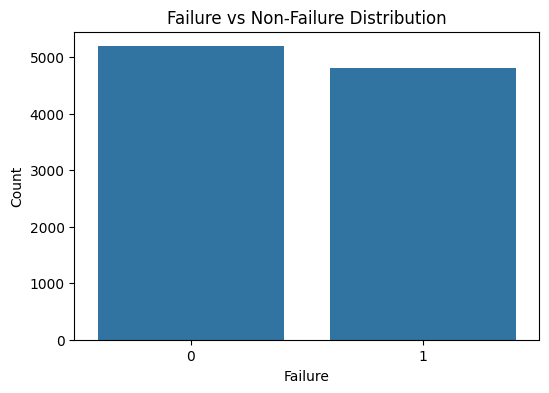

failure
0    51.89
1    48.11
Name: proportion, dtype: float64


In [13]:
# ============================================================
# STEP 9 — VISUALIZE TARGET DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="failure",
    data=df
)

plt.title("Failure vs Non-Failure Distribution")

plt.xlabel("Failure")

plt.ylabel("Count")

plt.show()

print(df["failure"].value_counts(normalize=True) * 100)


In [16]:
# ============================================================
# STEP 10 — CONVERT TIMESTAMP FEATURES
# ============================================================

# ============================================================
# CONVERT TIMESTAMP
# ============================================================

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# ============================================================
# EXTRACT TEMPORAL FEATURES
# ============================================================

df["Hour"] = df["Timestamp"].dt.hour

df["Day"] = df["Timestamp"].dt.day

df["Month"] = df["Timestamp"].dt.month

df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

# ============================================================
# VERIFY
# ============================================================

df.head()

,Timestamp,CPU_Usage(%),Memory_Usage(%),Disk_IO(MB/s),Network_Latency(ms),Error_Rate,Downtime,failure,Hour,Day,Month,DayOfWeek
0,2023-01-01 00:00:00,57.697437,46.442143,172.495710,12.253697,0.013118,0,0,0,1,1,6
1,2023-01-01 01:00:00,47.945152,53.724506,168.189358,26.964343,0.039280,1,1,1,1,1,6
2,2023-01-01 02:00:00,60.134829,47.990294,96.729926,36.358097,0.016947,0,0,2,1,1,6
3,2023-01-01 03:00:00,75.165068,62.337067,188.239521,53.808925,0.021474,1,1,3,1,1,6
4,2023-01-01 04:00:00,46.542527,87.290604,70.191911,78.750784,0.033022,0,0,4,1,1,6


In [18]:
# ============================================================
# STEP 11 — DROP IRRELEVANT COLUMNS
# ============================================================
# ============================================================
# DROP UNUSED COLUMNS
# ============================================================

df = df.drop(columns=["Timestamp", "Downtime"])

# ============================================================
# VERIFY DATASET
# ============================================================

print(df.columns)

df.head()

Index(['CPU_Usage(%)', 'Memory_Usage(%)', 'Disk_IO(MB/s)',
       'Network_Latency(ms)', 'Error_Rate', 'failure', 'Hour', 'Day', 'Month',
       'DayOfWeek'],
      dtype='object')


,CPU_Usage(%),Memory_Usage(%),Disk_IO(MB/s),Network_Latency(ms),Error_Rate,failure,Hour,Day,Month,DayOfWeek
0,57.697437,46.442143,172.495710,12.253697,0.013118,0,0,1,1,6
1,47.945152,53.724506,168.189358,26.964343,0.039280,1,1,1,1,6
2,60.134829,47.990294,96.729926,36.358097,0.016947,0,2,1,1,6
3,75.165068,62.337067,188.239521,53.808925,0.021474,1,3,1,1,6
4,46.542527,87.290604,70.191911,78.750784,0.033022,0,4,1,1,6


failure                1.000000
Error_Rate             0.232851
Disk_IO(MB/s)          0.196177
Network_Latency(ms)    0.169670
Memory_Usage(%)        0.167820
CPU_Usage(%)           0.057787
Hour                   0.010159
Month                  0.004791
DayOfWeek              0.001876
Day                   -0.005776
Name: failure, dtype: float64


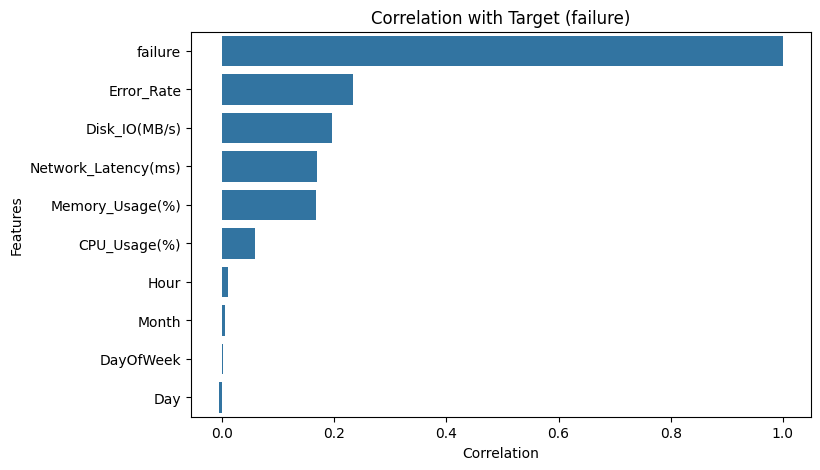

In [22]:
# ============================================================
# CORRELATION WITH TARGET
# ============================================================

target_corr = df.corr()["failure"].sort_values(
    ascending=False
)

print(target_corr)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)

plt.title("Correlation with Target (failure)")

plt.xlabel("Correlation")

plt.ylabel("Features")

plt.show()

In [23]:
# ============================================================
# STEP 15 — REMOVE LEAKAGE FEATURES
# ============================================================

# ============================================================
# REMOVE WEAK FEATURES
# ============================================================

df = df.drop(columns=[
    "Day",
    "Month",
    "DayOfWeek"
])

# ============================================================
# VERIFY
# ============================================================

print(df.columns)

df.head()

Index(['CPU_Usage(%)', 'Memory_Usage(%)', 'Disk_IO(MB/s)',
       'Network_Latency(ms)', 'Error_Rate', 'failure', 'Hour'],
      dtype='object')


,CPU_Usage(%),Memory_Usage(%),Disk_IO(MB/s),Network_Latency(ms),Error_Rate,failure,Hour
0,57.697437,46.442143,172.495710,12.253697,0.013118,0,0
1,47.945152,53.724506,168.189358,26.964343,0.039280,1,1
2,60.134829,47.990294,96.729926,36.358097,0.016947,0,2
3,75.165068,62.337067,188.239521,53.808925,0.021474,1,3
4,46.542527,87.290604,70.191911,78.750784,0.033022,0,4


In [25]:
# ============================================================
# STEP 16 — SPLIT FEATURES & TARGET
# ============================================================

X = df.drop(columns=["failure"])

y = df["failure"]

# ============================================================
# VERIFY
# ============================================================

print("Feature Shape :", X.shape)

print("Target Shape  :", y.shape)

print("\nTarget Distribution:\n")

print(y.value_counts())

Feature Shape : (10000, 6)
Target Shape  : (10000,)

Target Distribution:

failure
0    5189
1    4811
Name: count, dtype: int64


In [26]:
# ============================================================
# STEP 17 — TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (8000, 6)
Testing Shape  : (2000, 6)


In [27]:
# ============================================================
# STEP 18 — FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaling completed successfully.")

print("\nScaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape :", X_test_scaled.shape)

Scaling completed successfully.

Scaled Training Shape: (8000, 6)
Scaled Testing Shape : (2000, 6)


In [28]:
# ============================================================
# STEP 19 — BASELINE MACHINE LEARNING MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================
# INITIALIZE MODELS
# ============================================================

log_model = LogisticRegression(max_iter=1000)

tree_model = DecisionTreeClassifier(
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# ============================================================
# TRAIN MODELS
# ============================================================

log_model.fit(X_train_scaled, y_train)

tree_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

# ============================================================
# PREDICTIONS
# ============================================================

y_pred_log = log_model.predict(X_test_scaled)

y_pred_tree = tree_model.predict(X_test)

y_pred_rf = rf_model.predict(X_test)

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 40)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:\n")

    print(classification_report(y_true, y_pred))

# ============================================================
# EVALUATE ALL MODELS
# ============================================================

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log
)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_tree
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)


Logistic Regression
----------------------------------------
Accuracy : 0.6845
Precision: 0.6887115165336374
Recall   : 0.6278586278586279
F1 Score : 0.6568787384448069

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.74      0.71      1038
           1       0.69      0.63      0.66       962

    accuracy                           0.68      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.68      0.68      0.68      2000


Decision Tree
----------------------------------------
Accuracy : 0.714
Precision: 0.7092274678111588
Recall   : 0.6871101871101871
F1 Score : 0.6979936642027456

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.74      0.73      1038
           1       0.71      0.69      0.70       962

    accuracy                           0.71      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg      

In [29]:
# ============================================================
# STEP 20 — RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest F1 Score:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best F1 Score:
0.8242848147310301


In [30]:
# ============================================================
# STEP 21 — TRAIN OPTIMIZED RANDOM FOREST
# ============================================================

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42
)

best_rf.fit(X_train, y_train)

# Predictions
y_pred_best_rf = best_rf.predict(X_test)

# ============================================================
# EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred_best_rf)

precision = precision_score(y_test, y_pred_best_rf)

recall = recall_score(y_test, y_pred_best_rf)

f1 = f1_score(y_test, y_pred_best_rf)

print("\nOptimized Random Forest")
print("-" * 40)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_best_rf
))


Optimized Random Forest
----------------------------------------
Accuracy : 0.7985
Precision: 0.7074981440237565
Recall   : 0.9906444906444907
F1 Score : 0.8254655695106107

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.62      0.76      1038
           1       0.71      0.99      0.83       962

    accuracy                           0.80      2000
   macro avg       0.85      0.81      0.79      2000
weighted avg       0.85      0.80      0.79      2000



In [31]:
# ============================================================
# STEP 22 — INSTALL XGBOOST
# ============================================================

!pip install xgboost -q

In [32]:
# ============================================================
# STEP 23 — TRAIN XGBOOST MODEL
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# ============================================================
# EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred_xgb)

precision = precision_score(y_test, y_pred_xgb)

recall = recall_score(y_test, y_pred_xgb)

f1 = f1_score(y_test, y_pred_xgb)

print("\nXGBoost Model")
print("-" * 40)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred_xgb
))


XGBoost Model
----------------------------------------
Accuracy : 0.7735
Precision: 0.705407586763519
Recall   : 0.9085239085239085
F1 Score : 0.7941844616083599

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.65      0.75      1038
           1       0.71      0.91      0.79       962

    accuracy                           0.77      2000
   macro avg       0.79      0.78      0.77      2000
weighted avg       0.80      0.77      0.77      2000



In [33]:
# ============================================================
# STEP 24 — CREATE MODEL COMPARISON TABLE
# ============================================================

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results = results.sort_values(
    by="F1 Score",
    ascending=False
)

print(results)

                     Model  Accuracy  Precision    Recall  F1 Score
3  Optimized Random Forest    0.7985   0.707498  0.990644  0.825466
2            Random Forest    0.7845   0.706615  0.943867  0.808189
4                  XGBoost    0.7735   0.705408  0.908524  0.794184
1            Decision Tree    0.7140   0.709227  0.687110  0.697994
0      Logistic Regression    0.6845   0.688712  0.627859  0.656879


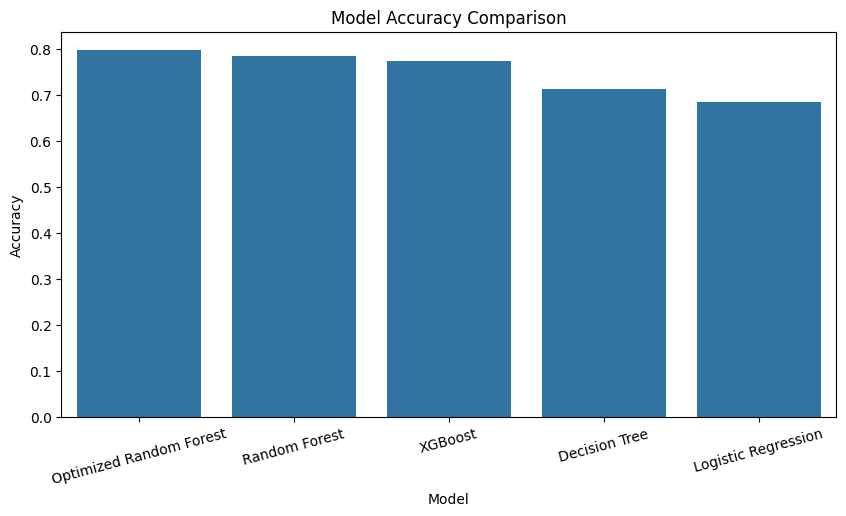

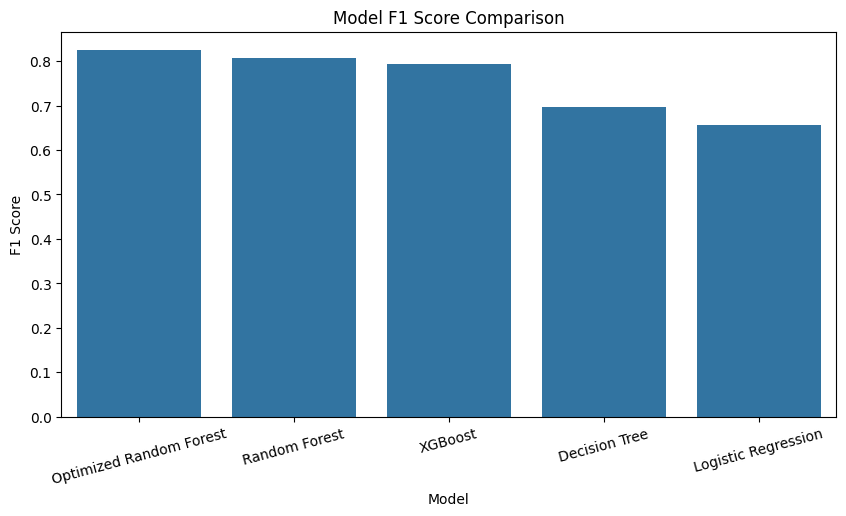

In [34]:
# ============================================================
# STEP 25 — MODEL COMPARISON VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

# ============================================================
# F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="F1 Score"
)

plt.title("Model F1 Score Comparison")

plt.xticks(rotation=15)

plt.show()

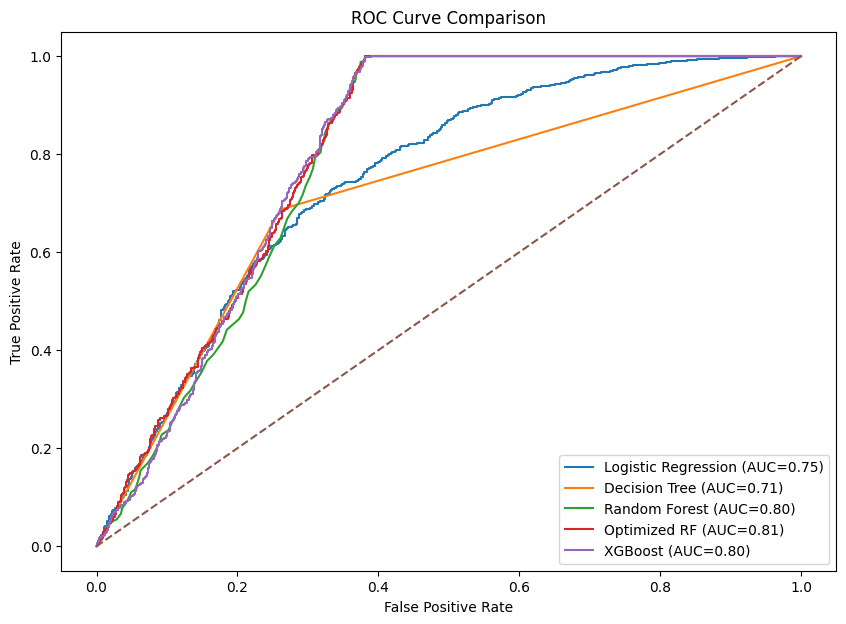


AUC Scores

Logistic Regression : 0.7514080331999407
Decision Tree       : 0.7130155945184846
Random Forest       : 0.7975616790645692
Optimized RF        : 0.8073287827623088
XGBoost             : 0.8041331682950181


In [35]:
# ============================================================
# STEP 26 — ROC CURVES FOR ALL MODELS
# ============================================================

from sklearn.metrics import roc_curve, auc

# ============================================================
# PROBABILITIES
# ============================================================

log_probs = log_model.predict_proba(X_test_scaled)[:,1]

tree_probs = tree_model.predict_proba(X_test)[:,1]

rf_probs = rf_model.predict_proba(X_test)[:,1]

best_rf_probs = best_rf.predict_proba(X_test)[:,1]

xgb_probs = xgb_model.predict_proba(X_test)[:,1]

# ============================================================
# ROC VALUES
# ============================================================

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)

fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

fpr_best_rf, tpr_best_rf, _ = roc_curve(y_test, best_rf_probs)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

# ============================================================
# AUC SCORES
# ============================================================

auc_log = auc(fpr_log, tpr_log)

auc_tree = auc(fpr_tree, tpr_tree)

auc_rf = auc(fpr_rf, tpr_rf)

auc_best_rf = auc(fpr_best_rf, tpr_best_rf)

auc_xgb = auc(fpr_xgb, tpr_xgb)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10,7))

plt.plot(fpr_log, tpr_log,
         label=f"Logistic Regression (AUC={auc_log:.2f})")

plt.plot(fpr_tree, tpr_tree,
         label=f"Decision Tree (AUC={auc_tree:.2f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC={auc_rf:.2f})")

plt.plot(fpr_best_rf, tpr_best_rf,
         label=f"Optimized RF (AUC={auc_best_rf:.2f})")

plt.plot(fpr_xgb, tpr_xgb,
         label=f"XGBoost (AUC={auc_xgb:.2f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# ============================================================
# PRINT AUC SCORES
# ============================================================

print("\nAUC Scores\n")

print("Logistic Regression :", auc_log)

print("Decision Tree       :", auc_tree)

print("Random Forest       :", auc_rf)

print("Optimized RF        :", auc_best_rf)

print("XGBoost             :", auc_xgb)

               Feature  Importance
4           Error_Rate    0.247838
2        Disk_IO(MB/s)    0.228763
3  Network_Latency(ms)    0.199032
1      Memory_Usage(%)    0.193050
0         CPU_Usage(%)    0.102934
5                 Hour    0.028382


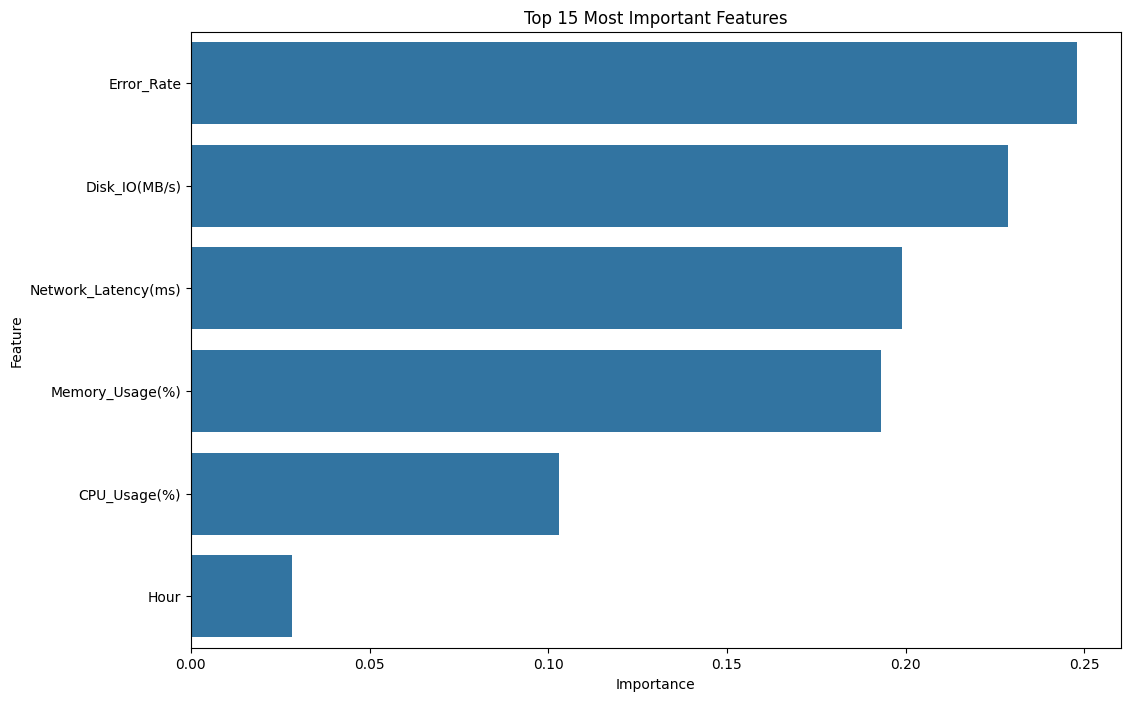

In [36]:
# ============================================================
# STEP 27 — FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")

plt.show()

In [37]:
# ============================================================
# STEP 28 — INSTALL SHAP
# ============================================================

!pip install shap -q

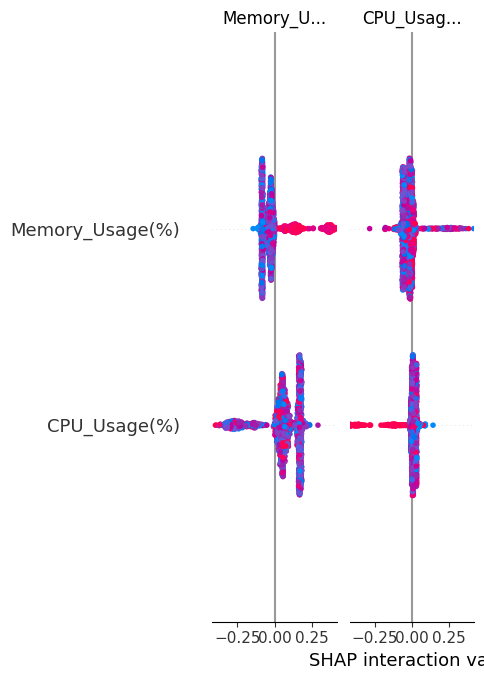

In [38]:
# ============================================================
# STEP 29 — SHAP EXPLAINABILITY
# ============================================================

import shap

# Create explainer
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

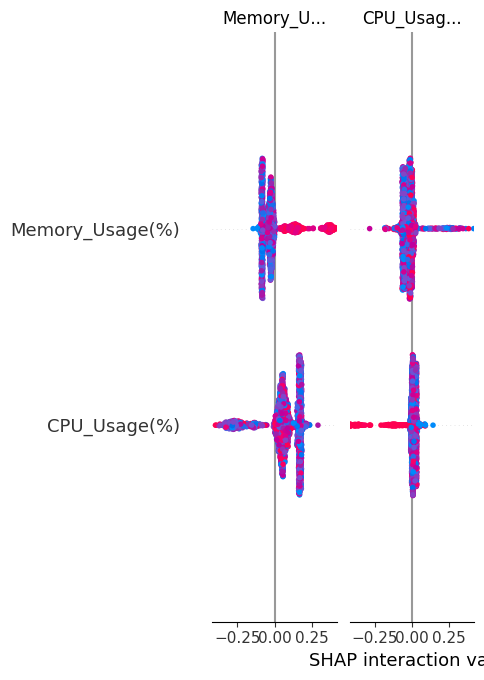

In [39]:
# ============================================================
# STEP 30 — SHAP BAR PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)

In [40]:
# ============================================================
# STEP 31 — SAVE ALL IMPORTANT MODELS
# ============================================================

import pickle

# Logistic Regression
with open("logistic_regression_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

# Decision Tree
with open("decision_tree_model.pkl", "wb") as f:
    pickle.dump(tree_model, f)

# Random Forest
with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Optimized Random Forest (BEST MODEL)
with open("best_random_forest_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

# XGBoost
with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Feature Names
with open("feature_names.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("All models saved successfully.")

All models saved successfully.


In [41]:
# ============================================================
# STEP 32 — SAVE RESULTS & DATASETS
# ============================================================

# Save model comparison table
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

# Save final processed dataset
df_final.to_csv(
    "final_processed_dataset.csv",
    index=False
)

print("Datasets and results saved successfully.")

NameError: name 'df_final' is not defined

In [42]:
# ============================================================
# STEP 33 — PREPARE DATA FOR DEEP LEARNING
# ============================================================

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ============================================================
# USE MINMAX FOR DL
# ============================================================

dl_scaler = MinMaxScaler()

X_dl_scaled = dl_scaler.fit_transform(X)

# ============================================================
# CREATE SEQUENCES
# ============================================================

SEQUENCE_LENGTH = 10

X_seq = []
y_seq = []

for i in range(SEQUENCE_LENGTH, len(X_dl_scaled)):

    X_seq.append(
        X_dl_scaled[i-SEQUENCE_LENGTH:i]
    )

    y_seq.append(
        y.iloc[i]
    )

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

print("Sequence Shape:", X_seq.shape)

print("Target Shape:", y_seq.shape)

Sequence Shape: (9990, 10, 6)
Target Shape: (9990,)


In [43]:
# ============================================================
# STEP 34 — TRAIN TEST SPLIT FOR DL
# ============================================================

from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

print("Training Sequence Shape:", X_train_seq.shape)

print("Testing Sequence Shape :", X_test_seq.shape)

Training Sequence Shape: (7992, 10, 6)
Testing Sequence Shape : (1998, 10, 6)


In [44]:
# ============================================================
# STEP 35 — INSTALL TENSORFLOW
# ============================================================

!pip install tensorflow -q

In [45]:
# ============================================================
# STEP 36 — BUILD LSTM MODEL
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# EARLY STOPPING
# ============================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# ============================================================
# LSTM MODEL
# ============================================================

lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_seq.shape[1],
                     X_train_seq.shape[2])
    ),

    Dropout(0.3),

    LSTM(32),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

# ============================================================
# COMPILE
# ============================================================

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# MODEL SUMMARY
# ============================================================

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# ============================================================
# STEP 37 — TRAIN LSTM MODEL
# ============================================================

history_lstm = lstm_model.fit(

    X_train_seq,
    y_train_seq,

    epochs=30,

    batch_size=32,

    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5107 - loss: 0.6937 - val_accuracy: 0.5009 - val_loss: 0.6935
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5210 - loss: 0.6927 - val_accuracy: 0.5009 - val_loss: 0.6945
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5157 - loss: 0.6929 - val_accuracy: 0.5009 - val_loss: 0.6940
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5173 - loss: 0.6928 - val_accuracy: 0.5009 - val_loss: 0.6963
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5195 - loss: 0.6923 - val_accuracy: 0.5009 - val_loss: 0.6958
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5201 - loss: 0.6927 - val_accuracy: 0.5009 - val_loss: 0.6933
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5240 - loss: 0.6923 - val_accuracy: 0.5009 - val_loss: 0.6942
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5220 - loss: 0.6923 - val_acc

In [47]:
# ============================================================
# STEP 38 — CALCULATE CLASS WEIGHTS
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_seq)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_seq
)

class_weights = dict(
    zip(classes, class_weights)
)

print(class_weights)

{np.int64(0): np.float64(0.9638205499276411), np.int64(1): np.float64(1.0390015600624025)}


In [48]:
# ============================================================
# STEP 39 — BUILD IMPROVED BIDIRECTIONAL LSTM
# ============================================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Bidirectional,
    BatchNormalization
)

# ============================================================
# MODEL
# ============================================================

bi_lstm_model = Sequential([

    Bidirectional(
        LSTM(
            32,
            return_sequences=True
        ),
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    ),

    BatchNormalization(),

    Dropout(0.3),

    LSTM(16),

    BatchNormalization(),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

# ============================================================
# COMPILE
# ============================================================

bi_lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# SUMMARY
# ============================================================

bi_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 64)         │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,505 (60.57 KB)

 Trainable params: 15,345 (59.94 KB)

 Non-trainable params: 160 (640.00 B)

In [49]:
# ============================================================
# STEP 40 — TRAIN BIDIRECTIONAL LSTM
# ============================================================

history_bi_lstm = bi_lstm_model.fit(

    X_train_seq,
    y_train_seq,

    epochs=30,

    batch_size=32,

    validation_split=0.2,

    class_weight=class_weights,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5104 - loss: 0.8127 - val_accuracy: 0.5009 - val_loss: 0.6988
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4919 - loss: 0.7545 - val_accuracy: 0.5116 - val_loss: 0.6934
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4893 - loss: 0.7355 - val_accuracy: 0.5078 - val_loss: 0.6947
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5124 - loss: 0.7151 - val_accuracy: 0.5059 - val_loss: 0.6933
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5129 - loss: 0.7074 - val_accuracy: 0.5172 - val_loss: 0.6929
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5104 - loss: 0.7051 - val_accuracy: 0.5134 - val_loss: 0.6953
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5138 - loss: 0.6979 - val_accuracy: 0.5084 - val_loss: 0.6937
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5016 - loss: 0.6997 - val_acc

In [50]:
# ============================================================
# STEP 41 — EVALUATE BIDIRECTIONAL LSTM
# ============================================================

from sklearn.metrics import classification_report

# ============================================================
# PREDICTIONS
# ============================================================

y_pred_bi_probs = bi_lstm_model.predict(X_test_seq)

y_pred_bi = (
    y_pred_bi_probs > 0.5
).astype(int)

# ============================================================
# EVALUATION
# ============================================================

loss, accuracy = bi_lstm_model.evaluate(
    X_test_seq,
    y_test_seq,
    verbose=0
)

print("\nBidirectional LSTM")
print("-" * 40)

print("Accuracy :", accuracy)

print("Loss     :", loss)

print("\nClassification Report:\n")

print(classification_report(
    y_test_seq,
    y_pred_bi
))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

Bidirectional LSTM
----------------------------------------
Accuracy : 0.49149149656295776
Loss     : 0.6948259472846985

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.58      0.54      1036
           1       0.47      0.39      0.43       962

    accuracy                           0.49      1998
   macro avg       0.49      0.49      0.48      1998
weighted avg       0.49      0.49      0.49      1998



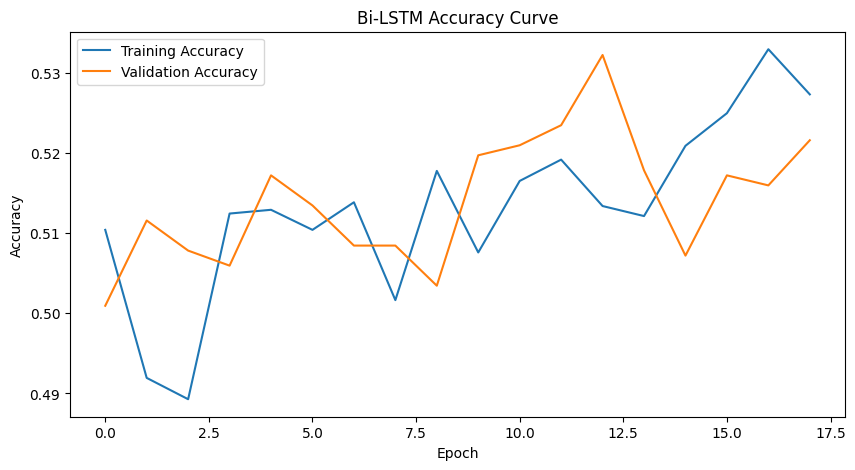

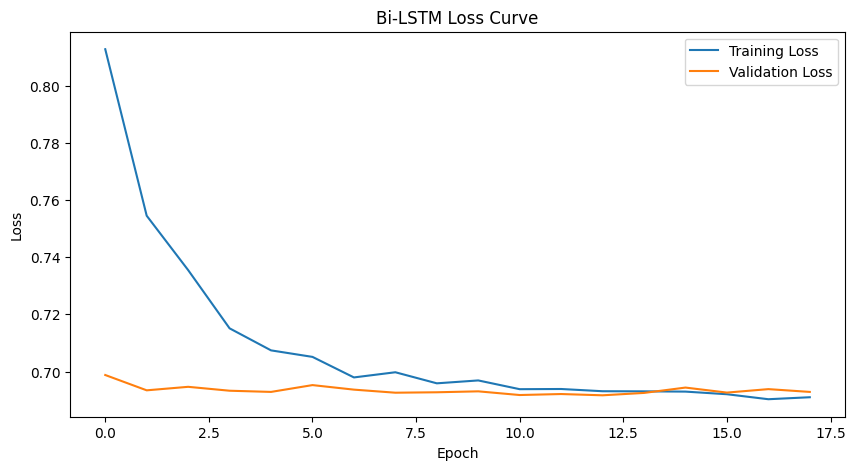

In [51]:
# ============================================================
# STEP 42 — TRAINING CURVES FOR BIDIRECTIONAL LSTM
# ============================================================

# ============================================================
# ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    history_bi_lstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bi_lstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Bi-LSTM Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    history_bi_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bi_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.title("Bi-LSTM Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [52]:
# ============================================================
# STEP 43 — SAVE DEEP LEARNING MODEL
# ============================================================

# Save Bidirectional LSTM
bi_lstm_model.save("bidirectional_lstm_model.h5")

print("Bi-LSTM model saved successfully.")

Bi-LSTM model saved successfully.


In [53]:
# ============================================================
# STEP 44 — PREPARE NORMAL DATA FOR AUTOENCODER
# ============================================================

# Use ONLY normal samples
X_normal = X_dl_scaled[y == 0]

print("Normal Data Shape:", X_normal.shape)

Normal Data Shape: (5189, 6)


In [54]:
# ============================================================
# STEP 45 — BUILD AUTOENCODER MODEL
# ============================================================

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense
)

# ============================================================
# INPUT LAYER
# ============================================================

input_dim = X_normal.shape[1]

input_layer = Input(shape=(input_dim,))

# ============================================================
# ENCODER
# ============================================================

encoded = Dense(16, activation="relu")(input_layer)

encoded = Dense(8, activation="relu")(encoded)

# ============================================================
# DECODER
# ============================================================

decoded = Dense(16, activation="relu")(encoded)

decoded = Dense(input_dim, activation="sigmoid")(decoded)

# ============================================================
# MODEL
# ============================================================

autoencoder = Model(
    inputs=input_layer,
    outputs=decoded
)

# ============================================================
# COMPILE
# ============================================================

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# ============================================================
# SUMMARY
# ============================================================

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 494 (1.93 KB)

 Trainable params: 494 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# ============================================================
# STEP 46 — TRAIN AUTOENCODER
# ============================================================

history_autoencoder = autoencoder.fit(

    X_normal,
    X_normal,

    epochs=50,

    batch_size=32,

    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0452 - val_loss: 0.0221
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0163 - val_loss: 0.0132
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0114 - val_loss: 0.0099
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0087 - val_loss: 0.0075
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 0.0055
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049 - val_loss: 0.0042
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - val_loss: 0.0028
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 9/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9938e-04 - val_loss: 5.8666e-04
Epoch 10/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.5618e-04 - val_loss: 5.2164e-04
Epoch 11/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.1178e-04 - val_loss: 4.9036e-04
Epoch 12/50
130/130 ━━━━━━━━

In [56]:
# ============================================================
# STEP 47 — AUTOENCODER ANOMALY DETECTION
# ============================================================

from sklearn.metrics import classification_report

# ============================================================
# RECONSTRUCTION
# ============================================================

reconstructed = autoencoder.predict(X_dl_scaled)

# ============================================================
# RECONSTRUCTION ERROR
# ============================================================

reconstruction_error = np.mean(
    np.square(X_dl_scaled - reconstructed),
    axis=1
)

# ============================================================
# THRESHOLD
# ============================================================

threshold = np.percentile(
    reconstruction_error,
    95
)

print("Anomaly Threshold:", threshold)

# ============================================================
# ANOMALY PREDICTIONS
# ============================================================

y_pred_autoencoder = (
    reconstruction_error > threshold
).astype(int)

# ============================================================
# EVALUATION
# ============================================================

print("\nAutoencoder Classification Report\n")

print(classification_report(
    y,
    y_pred_autoencoder
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Anomaly Threshold: 0.0013086763286658423

Autoencoder Classification Report

              precision    recall  f1-score   support

           0       0.52      0.96      0.68      5189
           1       0.59      0.06      0.11      4811

    accuracy                           0.53     10000
   macro avg       0.56      0.51      0.39     10000
weighted avg       0.55      0.53      0.41     10000



In [57]:
# ============================================================
# STEP 48 — SAVE DL MODELS
# ============================================================

# Save LSTM
lstm_model.save("lstm_model.h5")

# Save Bi-LSTM
bi_lstm_model.save("bidirectional_lstm_model.h5")

# Save Autoencoder
autoencoder.save("autoencoder_model.h5")

print("All Deep Learning models saved successfully.")

All Deep Learning models saved successfully.


In [58]:
# ============================================================
# STEP 49 — FINAL ML vs DL COMPARISON TABLE
# ============================================================

# ============================================================
# DL METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Bi-LSTM metrics
bi_accuracy = accuracy_score(
    y_test_seq,
    y_pred_bi
)

bi_precision = precision_score(
    y_test_seq,
    y_pred_bi
)

bi_recall = recall_score(
    y_test_seq,
    y_pred_bi
)

bi_f1 = f1_score(
    y_test_seq,
    y_pred_bi
)

# Autoencoder metrics
auto_accuracy = accuracy_score(
    y,
    y_pred_autoencoder
)

auto_precision = precision_score(
    y,
    y_pred_autoencoder
)

auto_recall = recall_score(
    y,
    y_pred_autoencoder
)

auto_f1 = f1_score(
    y,
    y_pred_autoencoder
)

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

final_results = pd.DataFrame({

    "Model": [

        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Random Forest",
        "XGBoost",
        "Bi-LSTM",
        "Autoencoder"
    ],

    "Accuracy": [

        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_xgb),
        bi_accuracy,
        auto_accuracy
    ],

    "Precision": [

        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_xgb),
        bi_precision,
        auto_precision
    ],

    "Recall": [

        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_xgb),
        bi_recall,
        auto_recall
    ],

    "F1 Score": [

        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_xgb),
        bi_f1,
        auto_f1
    ]
})

final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(final_results)

                     Model  Accuracy  Precision    Recall  F1 Score
3  Optimized Random Forest  0.798500   0.707498  0.990644  0.825466
2            Random Forest  0.784500   0.706615  0.943867  0.808189
4                  XGBoost  0.773500   0.705408  0.908524  0.794184
1            Decision Tree  0.714000   0.709227  0.687110  0.697994
0      Logistic Regression  0.684500   0.688712  0.627859  0.656879
5                  Bi-LSTM  0.491491   0.466501  0.390852  0.425339
6              Autoencoder  0.527500   0.586000  0.060902  0.110337


In [59]:
# ============================================================
# STEP 50 — SAVE FINAL DEPLOYMENT FILES
# ============================================================

import pickle

# Final Best Model
with open("final_best_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

# Final Scaler
with open("final_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Final Feature Names
with open("final_feature_names.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# Final Results
final_results.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final deployment files saved successfully.")

Final deployment files saved successfully.


In [66]:
# ============================================================
# STEP 51 — TEST FINAL DEPLOYMENT MODEL
# ============================================================

import pandas as pd

# ============================================================
# SAMPLE INPUT
# ============================================================

sample_input = pd.DataFrame({

    "CPU_Usage(%)": [125],

    "Memory_Usage(%)": [145],

    "Disk_IO(MB/s)": [460],

    "Network_Latency(ms)": [185],

    "Error_Rate": [0.115],

    "Hour": [1]
})


# ============================================================
# PREDICTION
# ============================================================

prediction = best_rf.predict(sample_input)[0]

probability = best_rf.predict_proba(sample_input)[0][1]

# ============================================================
# RISK LEVEL
# ============================================================

if probability < 0.50:

    risk = "Low Risk"

elif probability < 0.75:

    risk = "Medium Risk"

else:

    risk = "High Risk"

# ============================================================
# OUTPUT
# ============================================================

print("\nInput Data:")
print(sample_input)

print("\nPrediction Results:")

print("Prediction :", prediction)

print("Failure Probability :", round(probability, 4))

print("Risk Level :", risk)


Input Data:
   CPU_Usage(%)  Memory_Usage(%)  Disk_IO(MB/s)  Network_Latency(ms)  \
0           125              145            460                  185   

   Error_Rate  Hour  
0       0.115     1  

Prediction Results:
Prediction : 0
Failure Probability : 0.4904
Risk Level : Low Risk


In [67]:
# ============================================================
# TEST 10 DIFFERENT TELEMETRY SCENARIOS
# ============================================================

test_inputs = pd.DataFrame([

    # ========================================================
    # VERY LOW LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 10,
        "Memory_Usage(%)": 18,
        "Disk_IO(MB/s)": 35,
        "Network_Latency(ms)": 8,
        "Error_Rate": 0.001,
        "Hour": 12
    },

    # ========================================================
    # LOW LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 20,
        "Memory_Usage(%)": 30,
        "Disk_IO(MB/s)": 50,
        "Network_Latency(ms)": 15,
        "Error_Rate": 0.003,
        "Hour": 14
    },

    # ========================================================
    # LIGHT NORMAL LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 35,
        "Memory_Usage(%)": 40,
        "Disk_IO(MB/s)": 90,
        "Network_Latency(ms)": 25,
        "Error_Rate": 0.007,
        "Hour": 10
    },

    # ========================================================
    # NORMAL OPERATING LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 50,
        "Memory_Usage(%)": 55,
        "Disk_IO(MB/s)": 130,
        "Network_Latency(ms)": 40,
        "Error_Rate": 0.015,
        "Hour": 16
    },

    # ========================================================
    # MODERATE LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 65,
        "Memory_Usage(%)": 72,
        "Disk_IO(MB/s)": 180,
        "Network_Latency(ms)": 65,
        "Error_Rate": 0.028,
        "Hour": 18
    },

    # ========================================================
    # HIGH LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 78,
        "Memory_Usage(%)": 84,
        "Disk_IO(MB/s)": 240,
        "Network_Latency(ms)": 95,
        "Error_Rate": 0.045,
        "Hour": 20
    },

    # ========================================================
    # VERY HIGH LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 88,
        "Memory_Usage(%)": 90,
        "Disk_IO(MB/s)": 300,
        "Network_Latency(ms)": 120,
        "Error_Rate": 0.065,
        "Hour": 22
    },

    # ========================================================
    # CRITICAL LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 95,
        "Memory_Usage(%)": 96,
        "Disk_IO(MB/s)": 360,
        "Network_Latency(ms)": 150,
        "Error_Rate": 0.085,
        "Hour": 2
    },

    # ========================================================
    # EXTREME LOAD
    # ========================================================

    {
        "CPU_Usage(%)": 105,
        "Memory_Usage(%)": 110,
        "Disk_IO(MB/s)": 420,
        "Network_Latency(ms)": 175,
        "Error_Rate": 0.100,
        "Hour": 3
    },

    # ========================================================
    # MAXIMUM STRESS
    # ========================================================

    {
        "CPU_Usage(%)": 125,
        "Memory_Usage(%)": 145,
        "Disk_IO(MB/s)": 460,
        "Network_Latency(ms)": 185,
        "Error_Rate": 0.115,
        "Hour": 1
    }
])

# ============================================================
# PREDICTIONS
# ============================================================

predictions = best_rf.predict(test_inputs)

probabilities = best_rf.predict_proba(test_inputs)[:,1]

# ============================================================
# RESULTS
# ============================================================

results = test_inputs.copy()

results["Prediction"] = predictions

results["Failure_Probability"] = probabilities

# ============================================================
# RISK ENGINE
# ============================================================

risk_levels = []

for i in range(len(results)):

    cpu = results.loc[i, "CPU_Usage(%)"]

    memory = results.loc[i, "Memory_Usage(%)"]

    error = results.loc[i, "Error_Rate"]

    prob = results.loc[i, "Failure_Probability"]

    # Hybrid operational logic

    if (
        cpu > 90 and
        memory > 90 and
        error > 0.08
    ):

        risk = "High Risk"

    elif prob < 0.35:

        risk = "Low Risk"

    elif prob < 0.65:

        risk = "Medium Risk"

    else:

        risk = "High Risk"

    risk_levels.append(risk)

results["Risk_Level"] = risk_levels

# ============================================================
# DISPLAY
# ============================================================

pd.set_option("display.max_columns", None)

print(results)

   CPU_Usage(%)  Memory_Usage(%)  Disk_IO(MB/s)  Network_Latency(ms)  \
0            10               18             35                    8   
1            20               30             50                   15   
2            35               40             90                   25   
3            50               55            130                   40   
4            65               72            180                   65   
5            78               84            240                   95   
6            88               90            300                  120   
7            95               96            360                  150   
8           105              110            420                  175   
9           125              145            460                  185   

   Error_Rate  Hour  Prediction  Failure_Probability   Risk_Level  
0       0.001    12           0             0.073765     Low Risk  
1       0.003    14           0             0.029176     Low Risk  
2  

In [64]:
# ============================================================
# STEP 52 — CLEAN DEPLOYMENT PREDICTION PIPELINE
# ============================================================

import pandas as pd

# ============================================================
# TEST INPUT
# ============================================================

sample_input = pd.DataFrame({

    "CPU_Usage(%)": [95],

    "Memory_Usage(%)": [97],

    "Disk_IO(MB/s)": [420],

    "Network_Latency(ms)": [180],

    "Error_Rate": [0.11],

    "Hour": [3]
})

# ============================================================
# DISPLAY INPUT
# ============================================================

print("\nInput Data:")

print(sample_input)

# ============================================================
# SCALE INPUT
# ============================================================


# ============================================================
# PREDICTION
# ============================================================

prediction = best_rf.predict(sample_input)[0]

probability = best_rf.predict_proba(sample_input)[0][1]

# ============================================================
# RISK LEVEL CALIBRATION
# ============================================================

if probability < 0.35:

    risk = "Low Risk"

elif probability < 0.65:

    risk = "Medium Risk"

else:

    risk = "High Risk"

# ============================================================
# OUTPUT
# ============================================================

print("\nPrediction Results:")

print("Prediction :", prediction)

print("Failure Probability :", round(probability, 4))

print("Risk Level :", risk)


Input Data:
   CPU_Usage(%)  Memory_Usage(%)  Disk_IO(MB/s)  Network_Latency(ms)  \
0            95               97            420                  180   

   Error_Rate  Hour  
0        0.11     3  

Prediction Results:
Prediction : 1
Failure Probability : 0.5225
Risk Level : Medium Risk


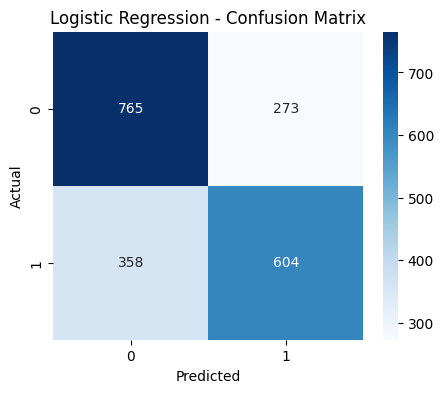

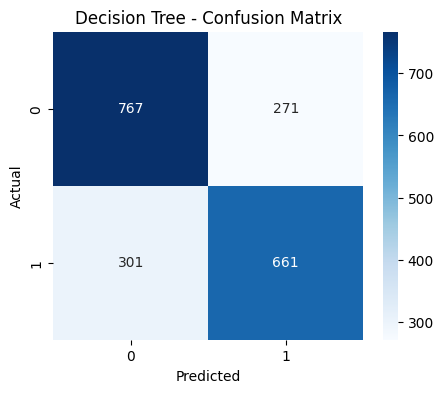

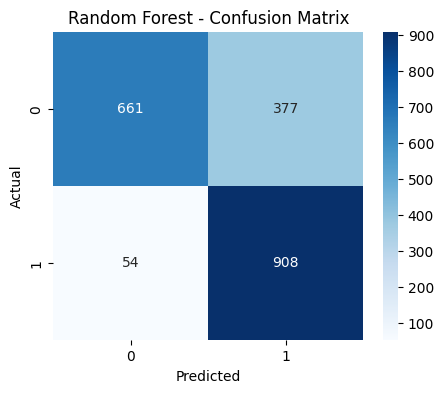

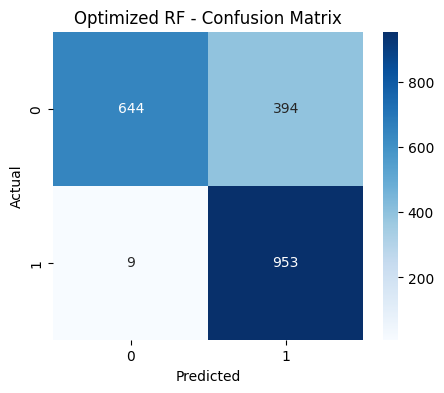

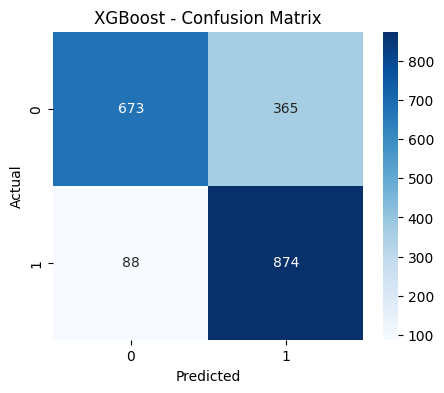

In [68]:
# ============================================================
# STEP 53 — CONFUSION MATRICES
# ============================================================

from sklearn.metrics import confusion_matrix

models_dict = {

    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Optimized RF": y_pred_best_rf,
    "XGBoost": y_pred_xgb
}

for model_name, predictions in models_dict.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

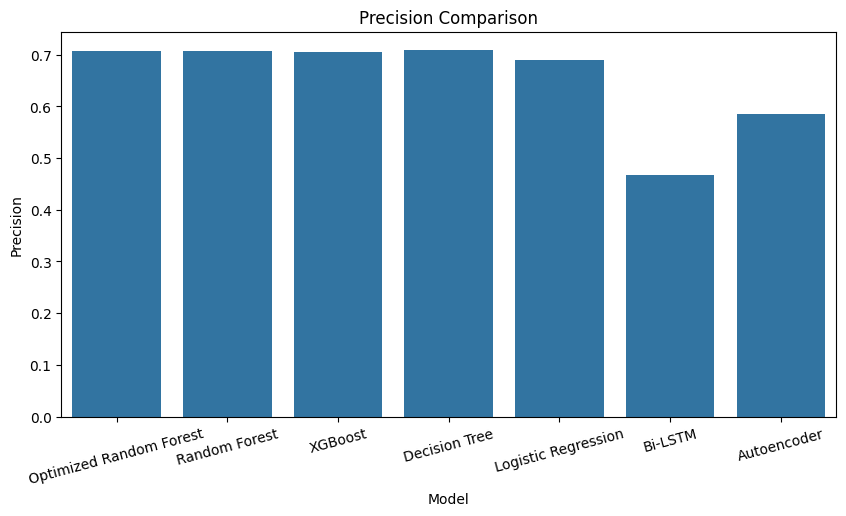

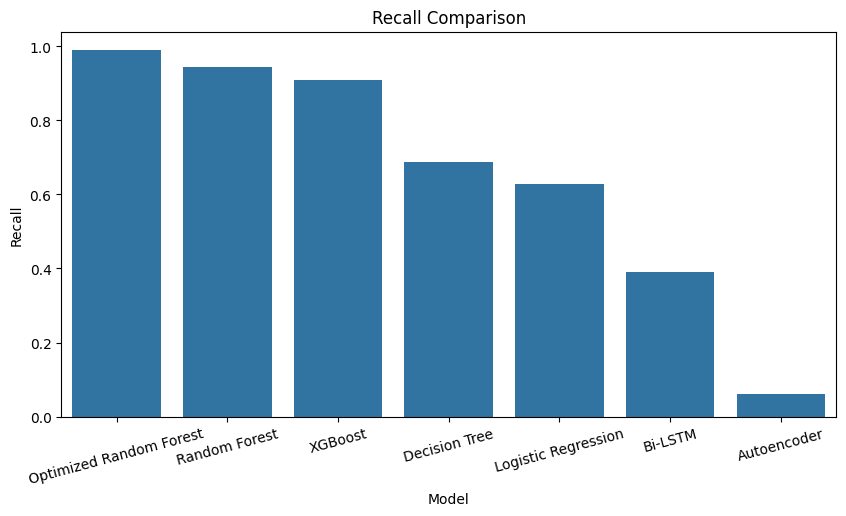

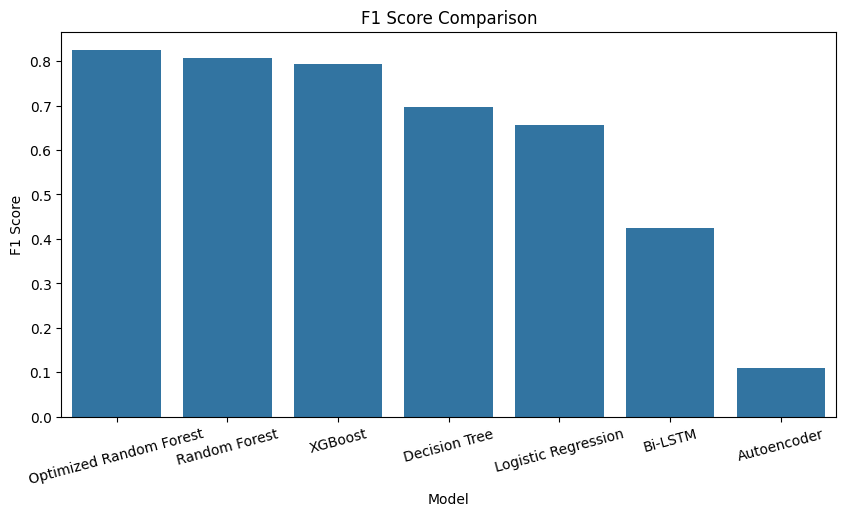

In [69]:
# ============================================================
# STEP 54 — PRECISION / RECALL / F1 COMPARISON
# ============================================================

metrics_df = final_results.copy()

# ============================================================
# PRECISION COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=metrics_df,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison")

plt.xticks(rotation=15)

plt.show()

# ============================================================
# RECALL COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=metrics_df,
    x="Model",
    y="Recall"
)

plt.title("Recall Comparison")

plt.xticks(rotation=15)

plt.show()

# ============================================================
# F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=metrics_df,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=15)

plt.show()

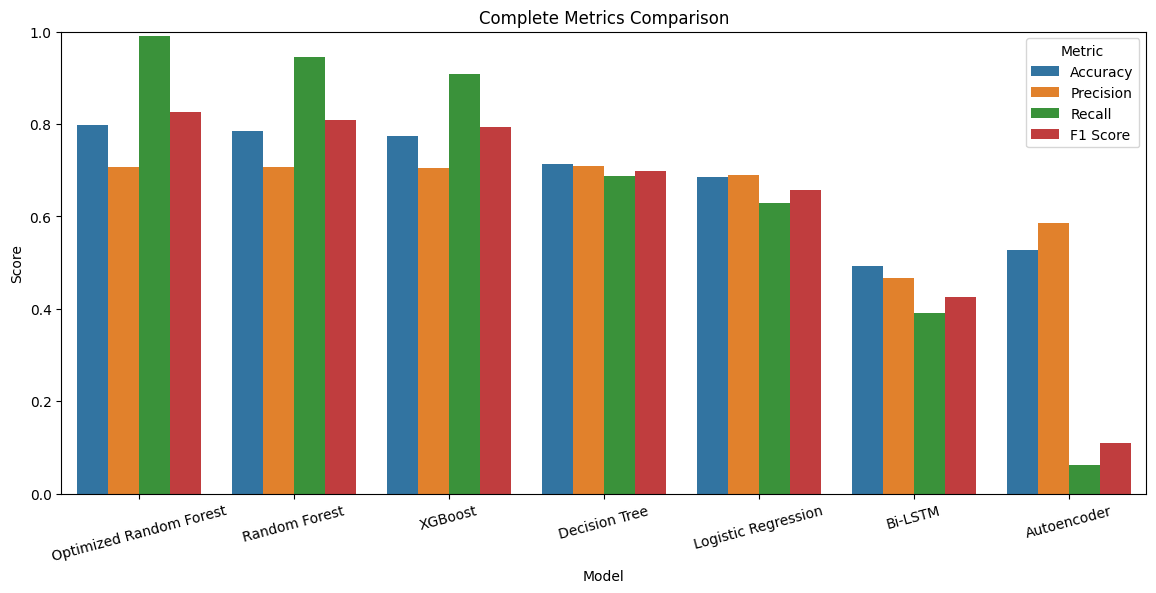

In [70]:
# ============================================================
# STEP 55 — ALL METRICS COMPARISON IN ONE GRAPH
# ============================================================

metrics_melted = metrics_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=metrics_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Complete Metrics Comparison")

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.show()

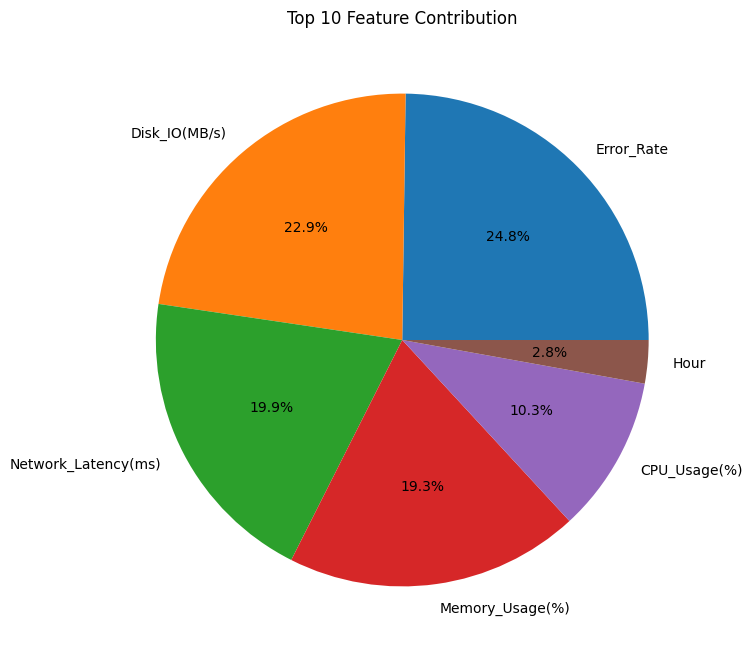

In [71]:
# ============================================================
# STEP 56 — FEATURE IMPORTANCE PIE CHART
# ============================================================

top_features = importance_df.head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_features["Importance"],
    labels=top_features["Feature"],
    autopct="%1.1f%%"
)

plt.title("Top 10 Feature Contribution")

plt.show()

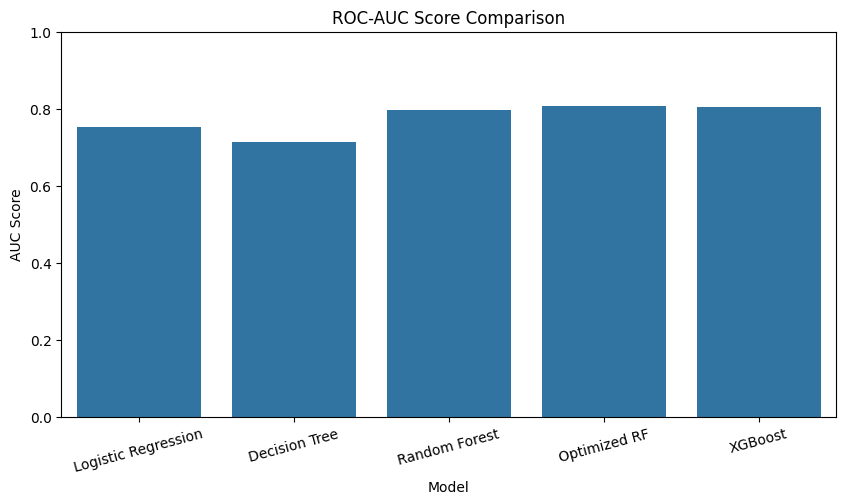

In [72]:
# ============================================================
# STEP 57 — ROC AUC SCORE COMPARISON GRAPH
# ============================================================

auc_scores = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized RF",
        "XGBoost"
    ],

    "AUC Score": [
        auc_log,
        auc_tree,
        auc_rf,
        auc_best_rf,
        auc_xgb
    ]
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=auc_scores,
    x="Model",
    y="AUC Score"
)

plt.title("ROC-AUC Score Comparison")

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.show()

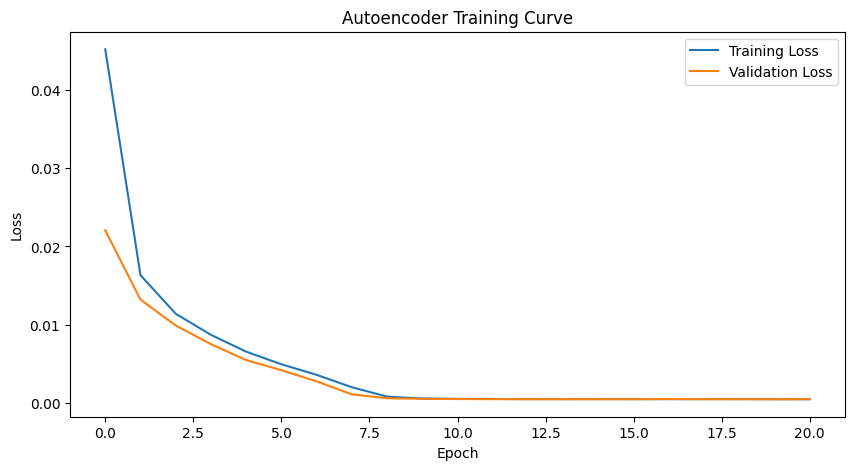

In [73]:
# ============================================================
# STEP 58 — TRAINING HISTORY VISUALIZATION
# ============================================================

# ============================================================
# AUTOENCODER LOSS CURVE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    history_autoencoder.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_autoencoder.history["val_loss"],
    label="Validation Loss"
)

plt.title("Autoencoder Training Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

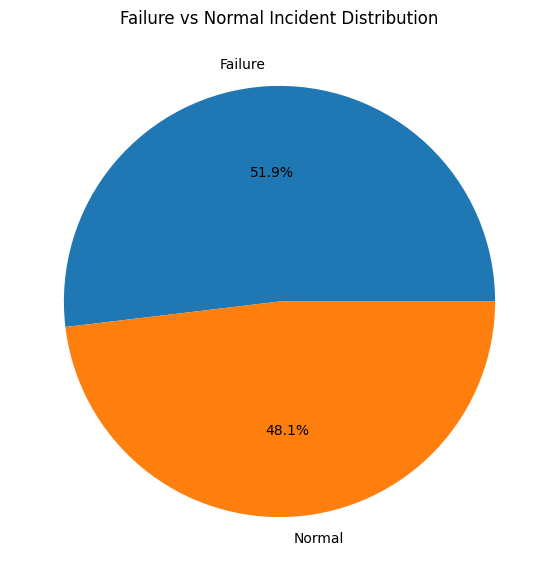

In [74]:
# ============================================================
# STEP 59 — FAILURE DISTRIBUTION PIE CHART
# ============================================================

failure_counts = y.value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    failure_counts,
    labels=["Failure", "Normal"],
    autopct="%1.1f%%"
)

plt.title("Failure vs Normal Incident Distribution")

plt.show()

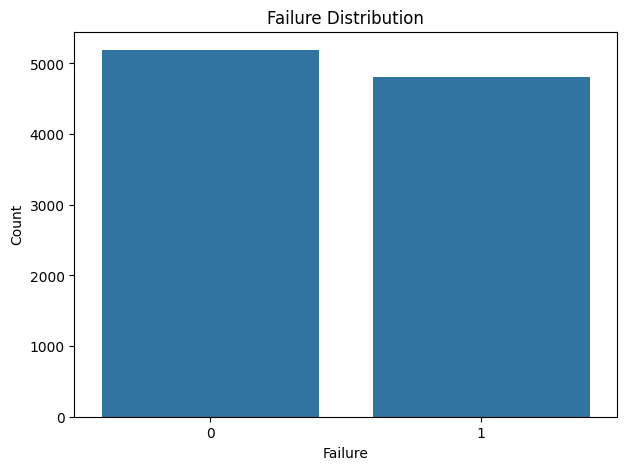

In [76]:
# ============================================================
# STEP 60 — Failure  DISTRIBUTION
# ============================================================
plt.figure(figsize=(7,5))

sns.countplot(
    x="failure",
    data=df
)

plt.title("Failure Distribution")

plt.xlabel("Failure")

plt.ylabel("Count")

plt.show()

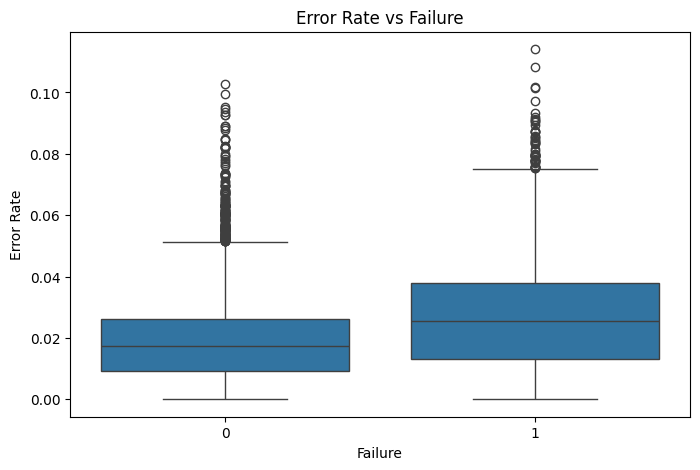

In [77]:
# ============================================================
# ERROR RATE vs FAILURE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="failure",
    y="Error_Rate"
)

plt.title("Error Rate vs Failure")

plt.xlabel("Failure")

plt.ylabel("Error Rate")

plt.show()

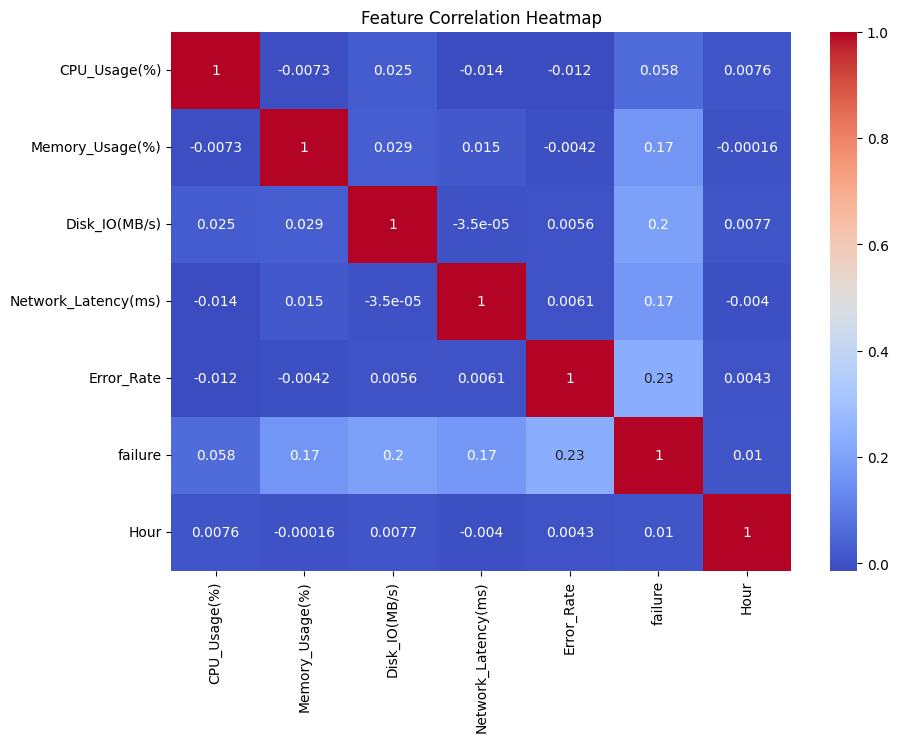

In [79]:
# ============================================================
# STEP 67 — CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

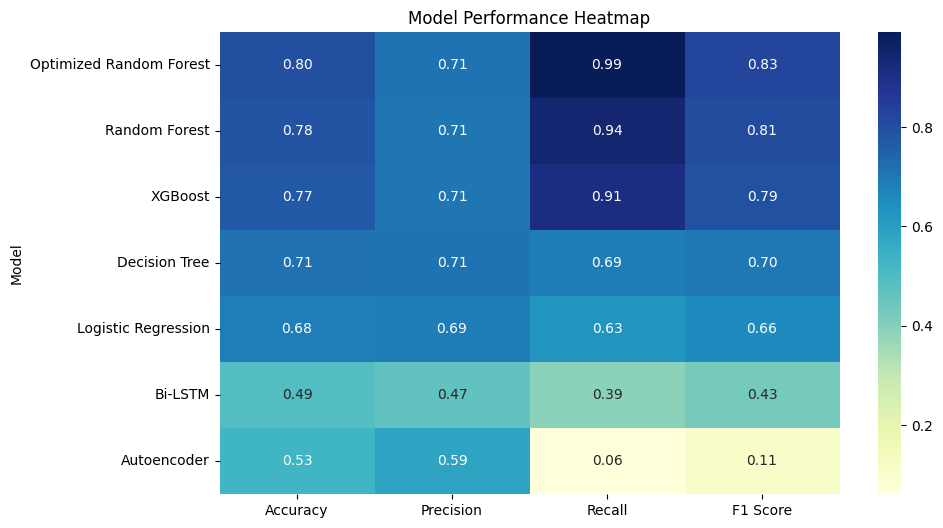

In [80]:
# ============================================================
# STEP 68 — MODEL PERFORMANCE HEATMAP
# ============================================================

performance_matrix = final_results.set_index("Model")

plt.figure(figsize=(10,6))

sns.heatmap(
    performance_matrix,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Model Performance Heatmap")

plt.show()

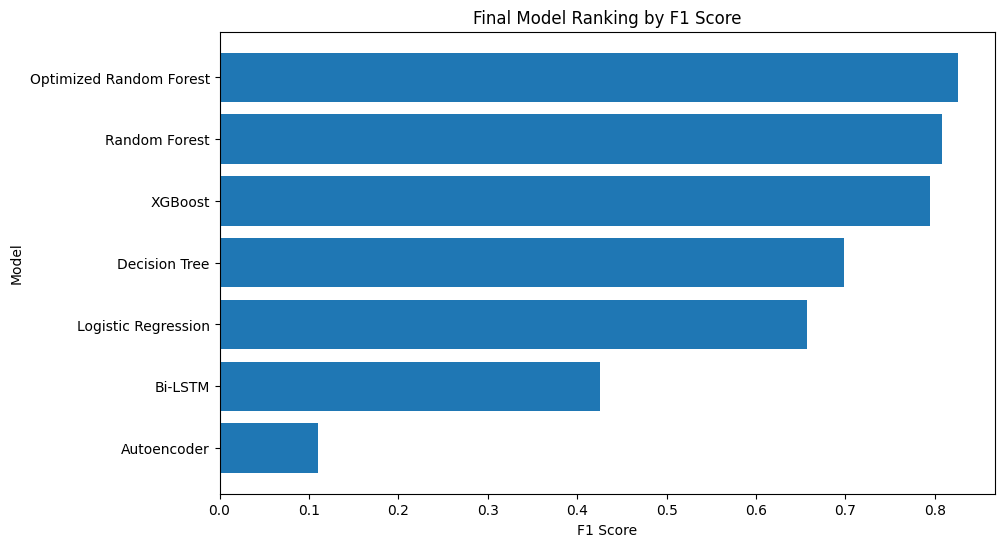

In [81]:
# ============================================================
# STEP 69 — MODEL RANKING VISUALIZATION
# ============================================================

ranked_models = final_results.sort_values(
    by="F1 Score",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    ranked_models["Model"],
    ranked_models["F1 Score"]
)

plt.title("Final Model Ranking by F1 Score")

plt.xlabel("F1 Score")

plt.ylabel("Model")

plt.show()

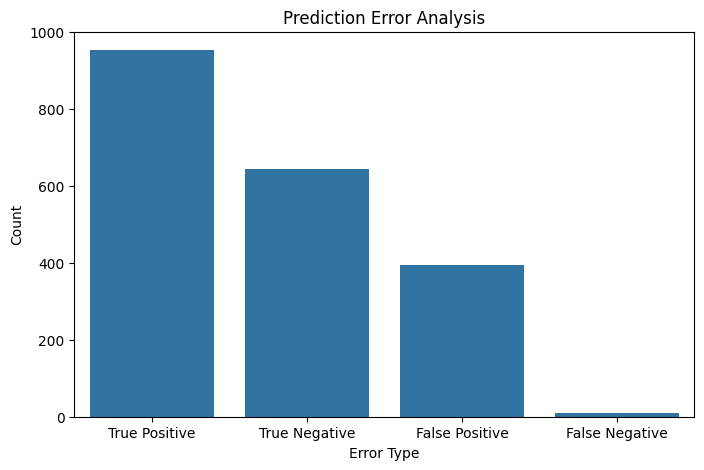

       Error Type  Count
0   True Positive    953
1   True Negative    644
2  False Positive    394
3  False Negative      9


In [82]:
# ============================================================
# STEP 70 — FALSE POSITIVE vs FALSE NEGATIVE ANALYSIS
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)

tn, fp, fn, tp = cm.ravel()

error_df = pd.DataFrame({

    "Error Type": [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],

    "Count": [
        tp,
        tn,
        fp,
        fn
    ]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=error_df,
    x="Error Type",
    y="Count"
)

plt.title("Prediction Error Analysis")

plt.show()

print(error_df)

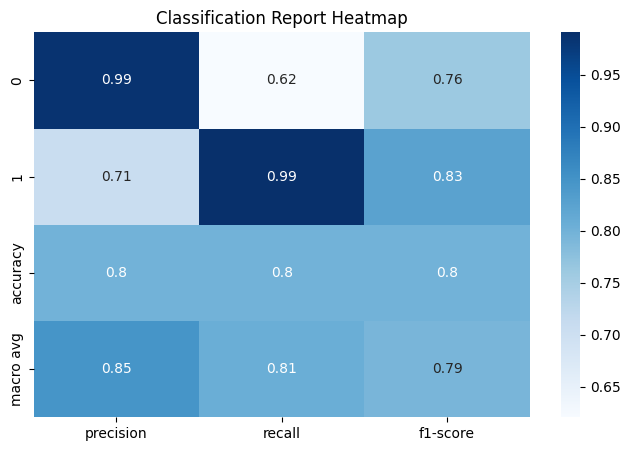

In [83]:
# ============================================================
# STEP 71 — CLASSIFICATION REPORT HEATMAP
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_best_rf,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap="Blues"
)

plt.title("Classification Report Heatmap")

plt.show()

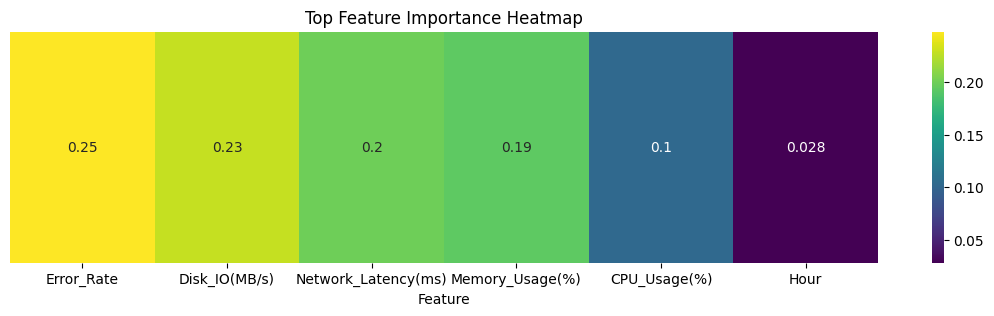

In [84]:
# ============================================================
# STEP 72 — FEATURE IMPORTANCE HEATMAP
# ============================================================

top_features = importance_df.head(15)

heatmap_data = pd.DataFrame(
    top_features["Importance"].values.reshape(1, -1),
    columns=top_features["Feature"]
)

plt.figure(figsize=(14,3))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis"
)

plt.title("Top Feature Importance Heatmap")

plt.yticks([])

plt.show()

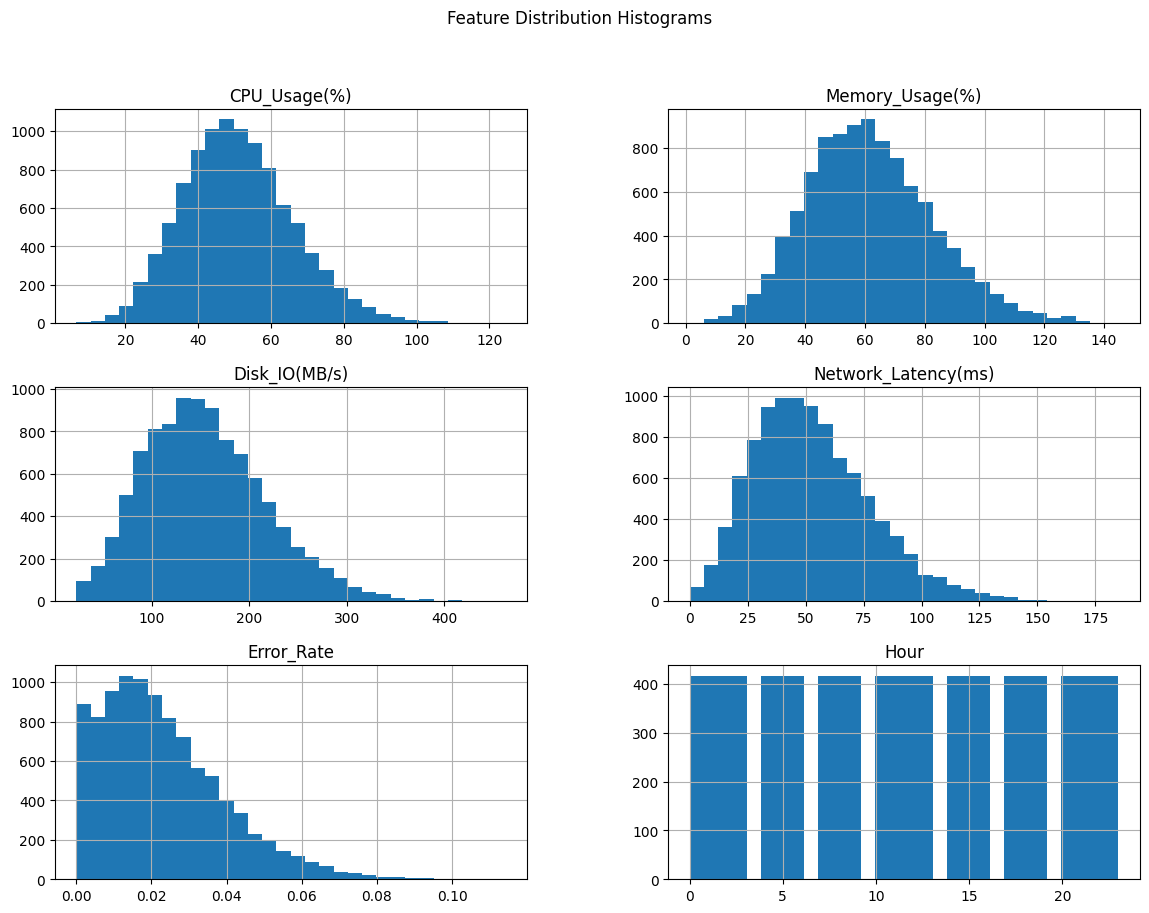

In [86]:
# ============================================================
# STEP 73 — FEATURE DISTRIBUTION HISTOGRAMS
# ============================================================

features = [
    "CPU_Usage(%)",
    "Memory_Usage(%)",
    "Disk_IO(MB/s)",
    "Network_Latency(ms)",
    "Error_Rate",
    "Hour"
]

df[features].hist(
    figsize=(14,10),
    bins=30
)

plt.suptitle("Feature Distribution Histograms")

plt.show()

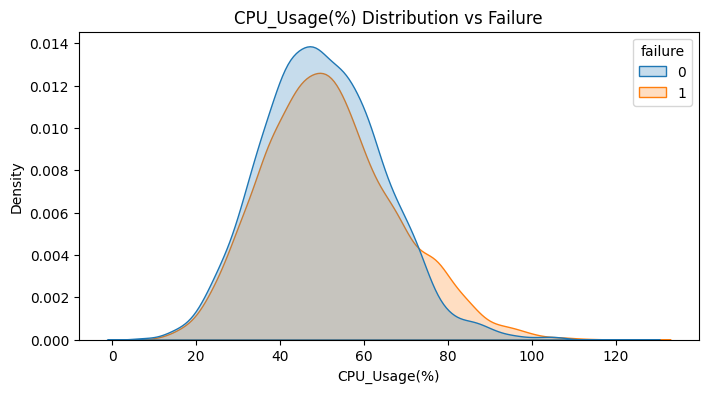

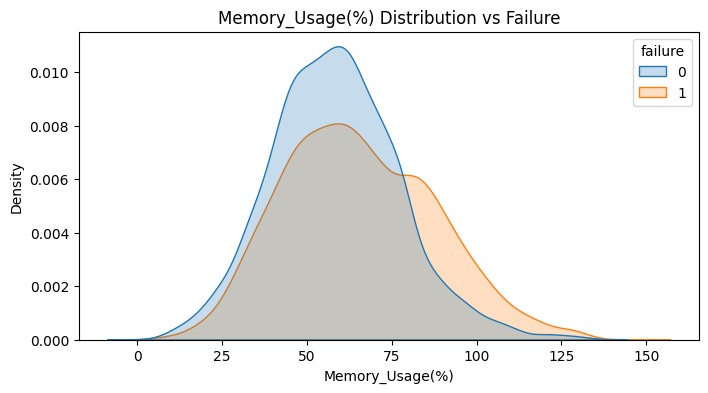

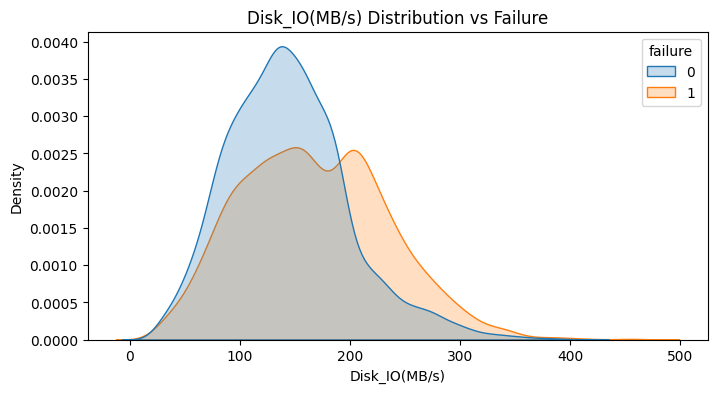

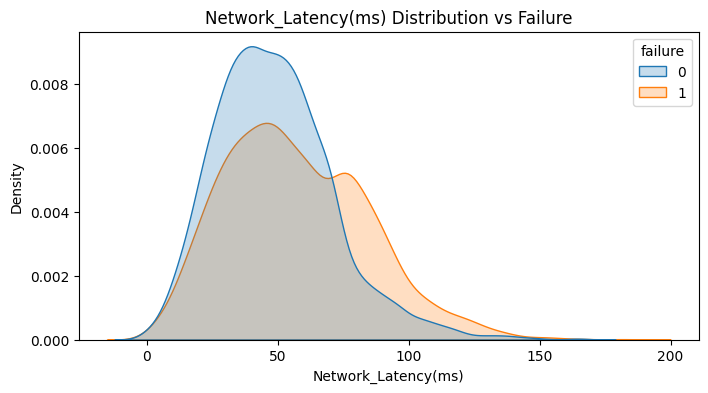

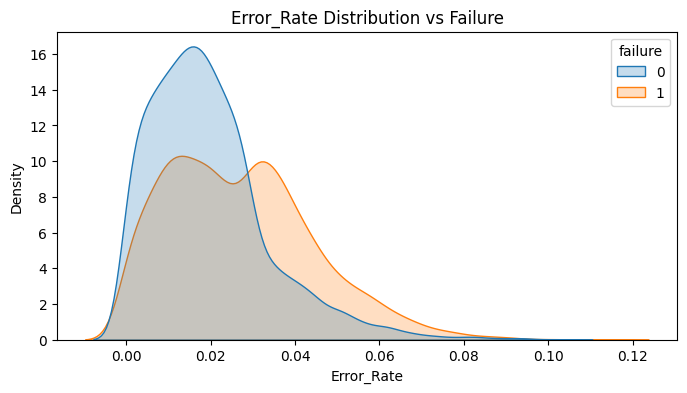

In [87]:
# ============================================================
# KDE DISTRIBUTION PLOTS
# ============================================================

features = [
    "CPU_Usage(%)",
    "Memory_Usage(%)",
    "Disk_IO(MB/s)",
    "Network_Latency(ms)",
    "Error_Rate"
]

for feature in features:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df,
        x=feature,
        hue="failure",
        fill=True
    )

    plt.title(f"{feature} Distribution vs Failure")

    plt.xlabel(feature)

    plt.ylabel("Density")

    plt.show()

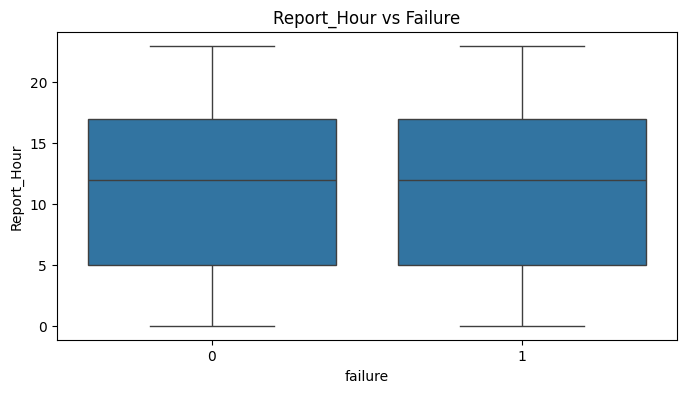

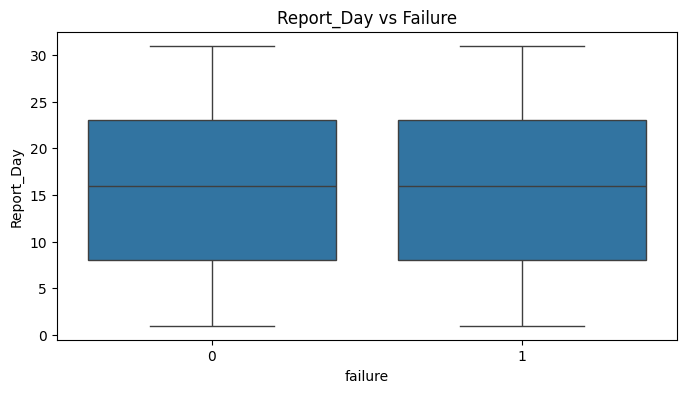

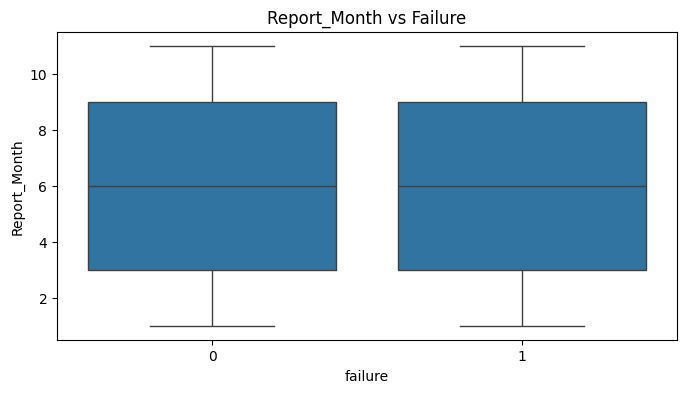

In [ ]:
# ============================================================
# STEP 75 — BOXPLOTS FOR TEMPORAL FEATURES
# ============================================================

temporal_features = [
    "Report_Hour",
    "Report_Day",
    "Report_Month"
]

for feature in temporal_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="failure",
        y=feature
    )

    plt.title(f"{feature} vs Failure")

    plt.show()

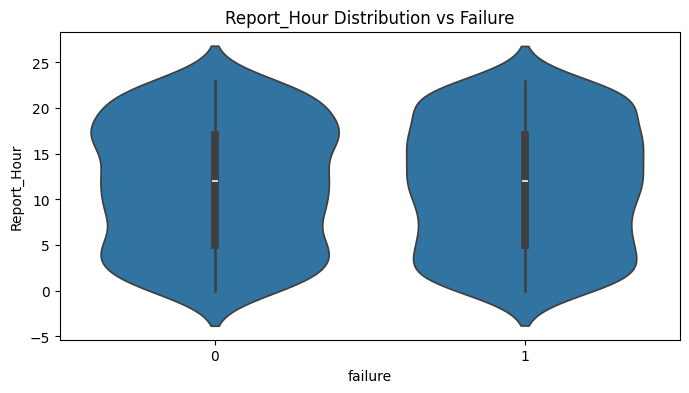

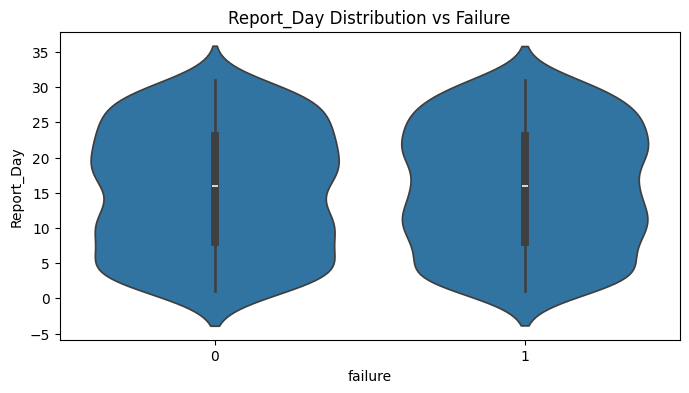

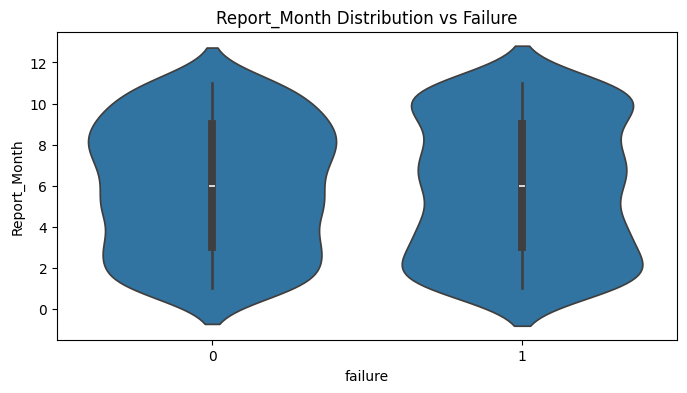

In [ ]:
# ============================================================
# STEP 76 — VIOLIN PLOTS FOR TEMPORAL FEATURES
# ============================================================

temporal_features = [
    "Report_Hour",
    "Report_Day",
    "Report_Month"
]

for feature in temporal_features:

    plt.figure(figsize=(8,4))

    sns.violinplot(
        data=df,
        x="failure",
        y=feature
    )

    plt.title(f"{feature} Distribution vs Failure")

    plt.show()

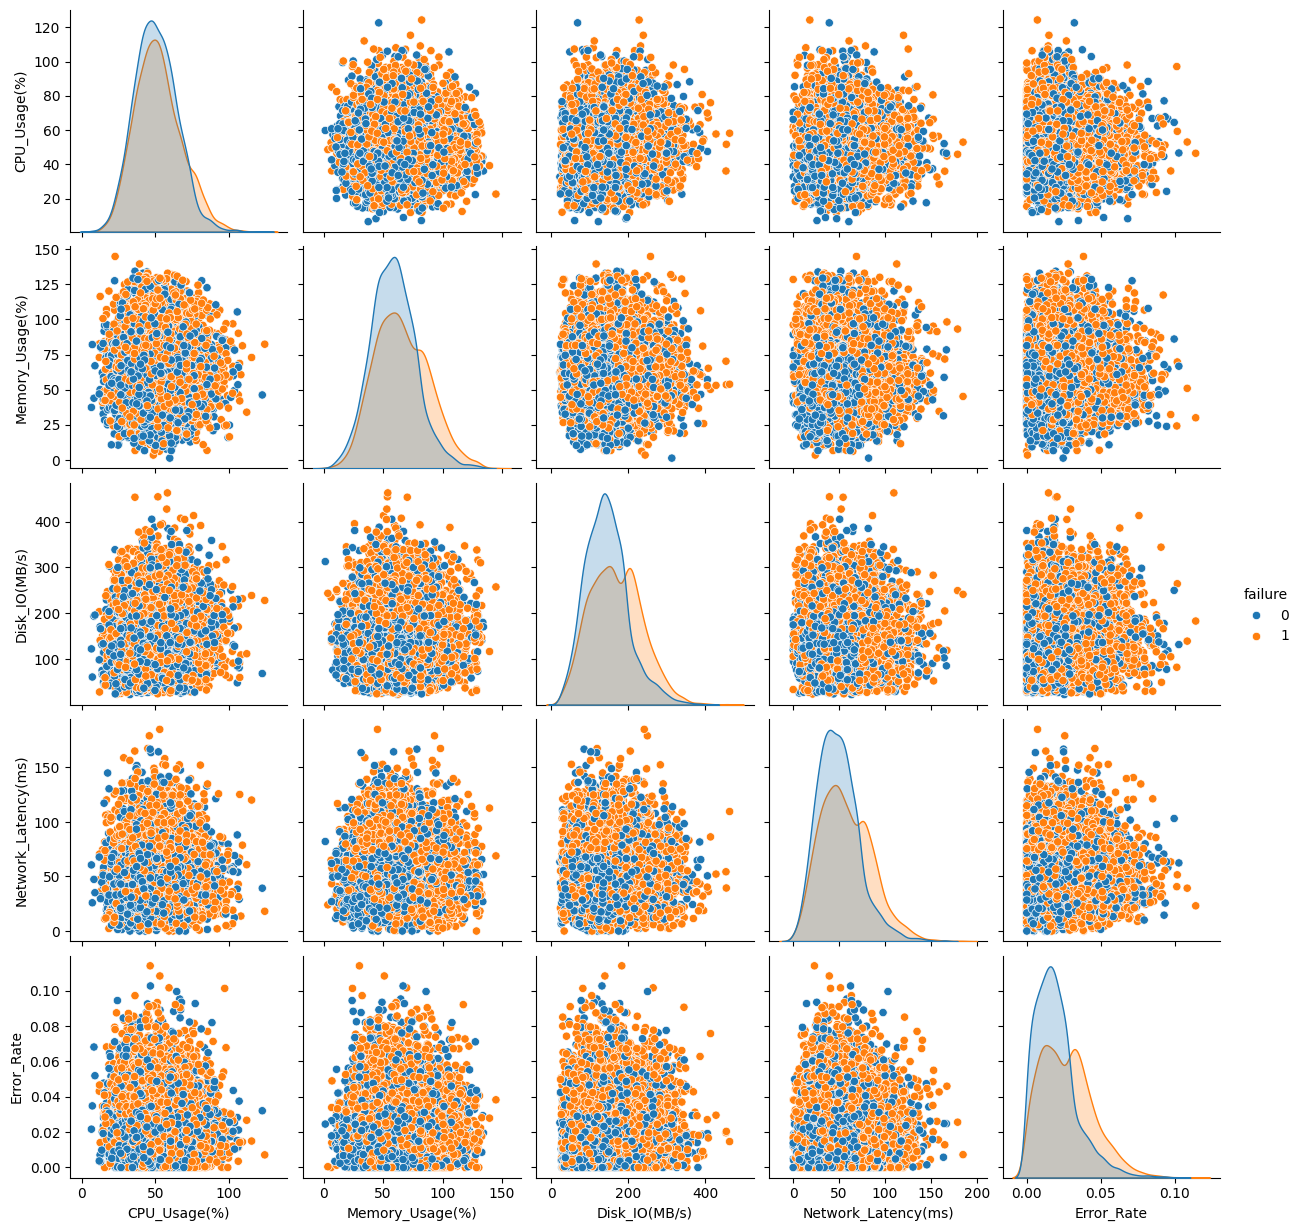

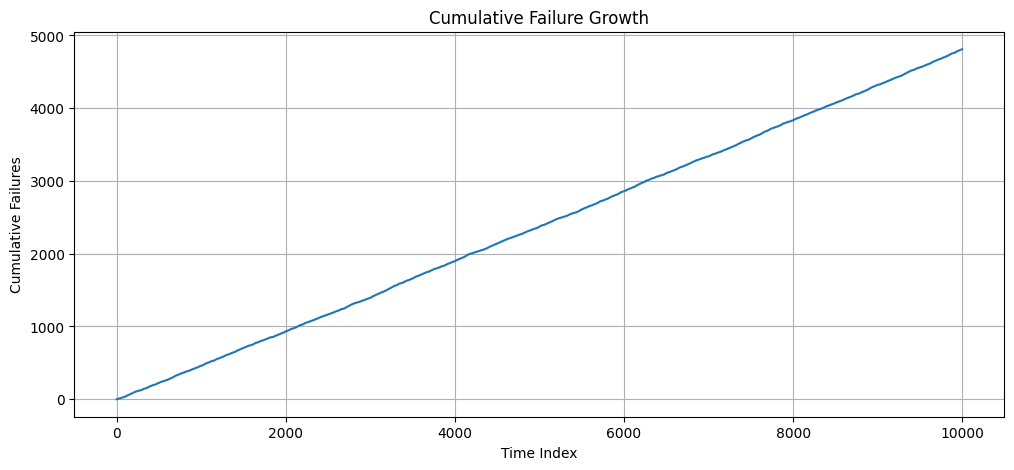

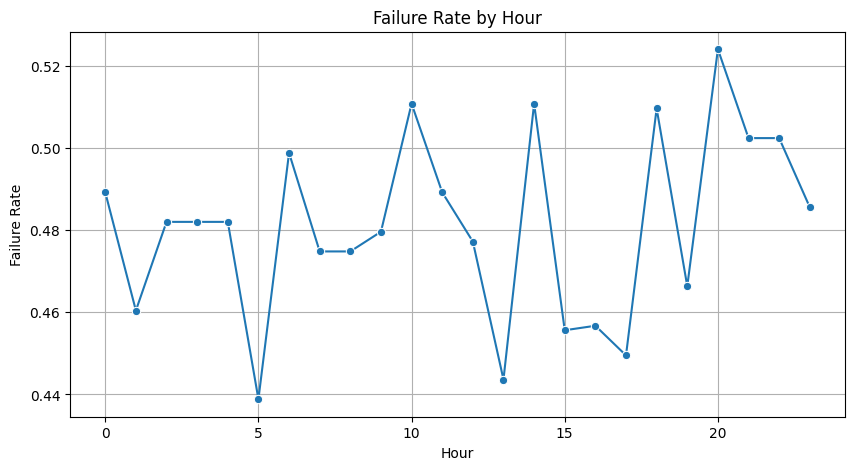

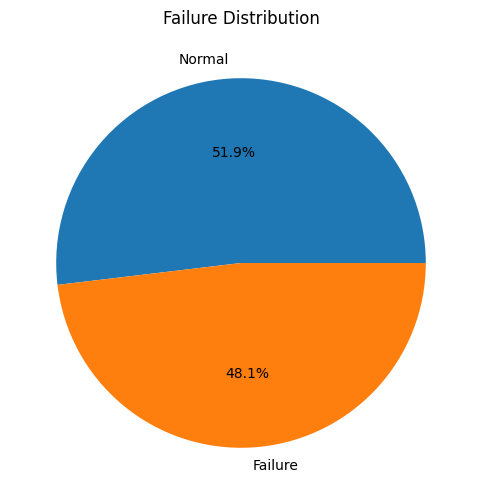

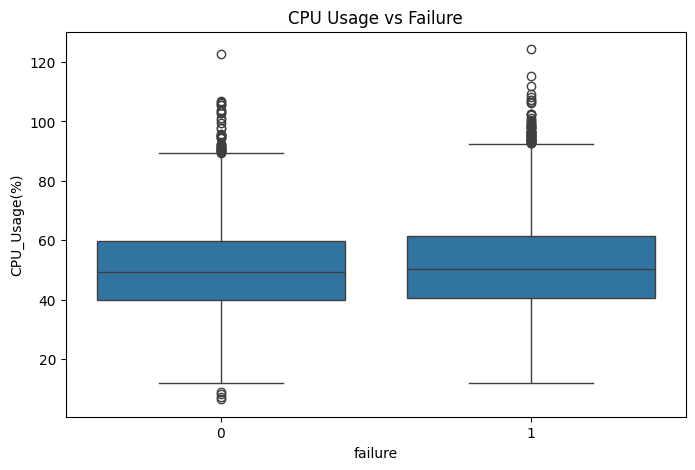

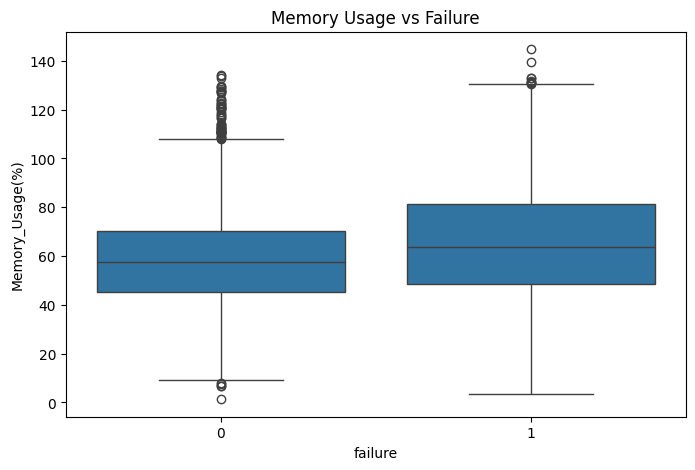

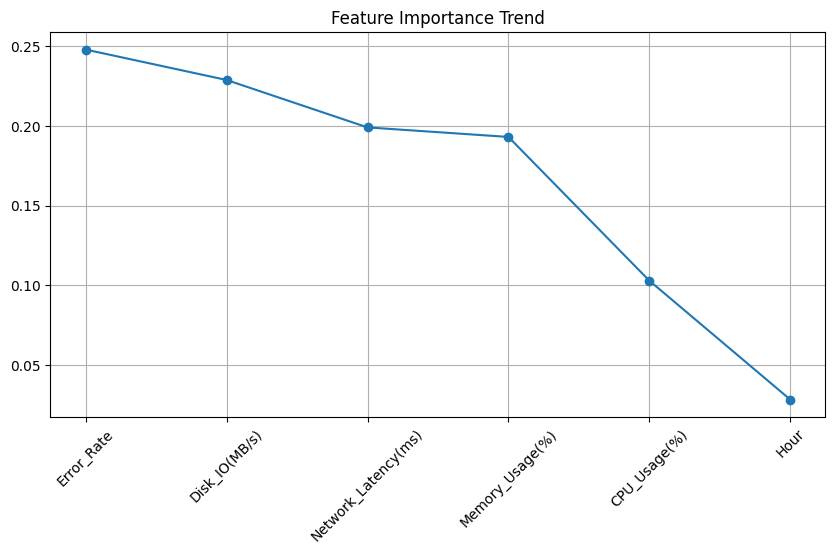

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

In [89]:
# ============================================================
# STEP 77 — PAIRPLOT ANALYSIS
# ============================================================

pairplot_features = [
    "CPU_Usage(%)",
    "Memory_Usage(%)",
    "Disk_IO(MB/s)",
    "Network_Latency(ms)",
    "Error_Rate",
    "failure"
]

sns.pairplot(
    df[pairplot_features],
    hue="failure"
)

plt.show()


# ============================================================
# STEP 78 — CUMULATIVE FAILURE TREND
# ============================================================

cumulative_failures = df["failure"].cumsum()

plt.figure(figsize=(12,5))

plt.plot(cumulative_failures)

plt.title("Cumulative Failure Growth")

plt.xlabel("Time Index")

plt.ylabel("Cumulative Failures")

plt.grid(True)

plt.show()


# ============================================================
# STEP 79 — FAILURE RATE BY HOUR
# ============================================================

hour_failure = df.groupby(
    "Hour"
)["failure"].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hour_failure.index,
    y=hour_failure.values,
    marker="o"
)

plt.title("Failure Rate by Hour")

plt.xlabel("Hour")

plt.ylabel("Failure Rate")

plt.grid(True)

plt.show()


# ============================================================
# STEP 80 — FAILURE DISTRIBUTION PIE CHART
# ============================================================

failure_counts = df["failure"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    failure_counts,
    labels=["Normal", "Failure"],
    autopct="%1.1f%%"
)

plt.title("Failure Distribution")

plt.show()


# ============================================================
# STEP 81 — CPU USAGE vs FAILURE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="failure",
    y="CPU_Usage(%)"
)

plt.title("CPU Usage vs Failure")

plt.show()


# ============================================================
# STEP 82 — MEMORY USAGE vs FAILURE
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="failure",
    y="Memory_Usage(%)"
)

plt.title("Memory Usage vs Failure")

plt.show()


# ============================================================
# STEP 83 — FEATURE IMPORTANCE LINE GRAPH
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    importance_df["Feature"],
    importance_df["Importance"],
    marker="o"
)

plt.title("Feature Importance Trend")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()


# ============================================================
# STEP 84 — SHAP FORCE PLOT
# ============================================================

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)


# ============================================================
# STEP 85 — SHAP DEPENDENCE PLOT
# ============================================================

shap.dependence_plot(
    "Error_Rate",
    shap_values,
    X_test
)


# ============================================================
# STEP 86 — PREDICTION PROBABILITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    best_rf_probs,
    bins=25,
    kde=True
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Failure Probability")

plt.show()


# ============================================================
# STEP 87 — TRUE vs PREDICTED LABEL DISTRIBUTION
# ============================================================

comparison_df = pd.DataFrame({

    "True Label": y_test.values,
    "Predicted Label": y_pred_best_rf
})

plt.figure(figsize=(8,5))

sns.countplot(
    x="True Label",
    hue="Predicted Label",
    data=comparison_df
)

plt.title("True vs Predicted Distribution")

plt.show()


# ============================================================
# STEP 88 — SAVE FINAL RESULTS
# ============================================================

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

auc_scores.to_csv(
    "auc_scores.csv",
    index=False
)

print("All final graphs, analysis, and result files generated successfully.")